# Capstone Project 2026: Data-Driven Stock Analysis using Time Series Models

**Name:** Lakshya gupta
**Date:** May 2026

---

## Project Overview
End-to-end time series forecasting pipeline for NSE-listed stocks covering all 8 capstone tasks:
stock selection -> preprocessing -> ARIMA / Prophet / LSTM forecasting -> volatility analysis ->
portfolio construction -> model comparison -> StockGro virtual trading -> performance tracking.

| Parameter | Value |
|-----------|-------|
| **Data Source** | Yahoo Finance (`yfinance`) |
| **Period** | 1 Jan 2021 – 31 Dec 2025 |
| **Interval** | Daily (1d) |
| **Train Set** | Jan 2021 – Jun 2025 |
| **Test Set** | Jul 2025 – Dec 2025 |
| **Forecast Window** | 2 trading days (StockGro: May 11–15 2026) |
| **Virtual Capital** | ₹10,00,000 |

In [65]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
from itertools import product

# Statsmodels
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# GARCH
from arch import arch_model

# Prophet (optional)
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
    print('Prophet loaded.')
except ImportError:
    PROPHET_AVAILABLE = False
    print('Prophet not available — install with: pip install prophet')

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.2f}'.format)
np.random.seed(42)
tf.random.set_seed(42)

print('All libraries loaded.')

Prophet loaded.
All libraries loaded.


---
## Task 1: Stock Universe Selection

**Methodology — Sector Momentum → Stock Selection (2 steps)**

**Step 1:** Download NSE sector indices (Nifty 50, Bank, IT, Auto, Metal, Pharma) and compare
cumulative returns 2021–2025 to identify which sectors had the strongest momentum.

**Step 2:** From the top-performing sectors, pick one liquid large-cap stock per sector using:
- **Rolling 30-day std dev** (volatility profile — prefer stocks with interesting but not excessive risk)
- **STL trend component** (is the stock in an uptrend entering 2026?)
- **Sector-based rationale** (leader stock = cleanest signal)

| Stock | Sector | Justification |
|-------|--------|---------------|
| HDFCBANK.NS | Banking | Largest private bank; consistent trend; moderate volatility |
| TCS.NS | IT | IT sector was a top-2 performer 2021–2025; TCS is the sector bellwether |
| SUNPHARMA.NS | Pharma | Pharma had strong defensive momentum in H2 2024–2025 |
| HINDUNILVR.NS | FMCG | Low-volatility anchor; negative correlation with cyclicals |
| MARUTI.NS | Auto | India's largest passenger vehicle manufacturer; strong FCF; Auto sector top performer at +196% |

In [66]:
# ── Global configuration ─────────────────────────────────────────────
TICKERS = ['HDFCBANK.NS', 'TCS.NS', 'SUNPHARMA.NS', 'HINDUNILVR.NS', 'MARUTI.NS']
SECTOR_MAP = {
    'HDFCBANK.NS':   'Banking',
    'TCS.NS':        'IT',
    'SUNPHARMA.NS':  'Pharma',
    'HINDUNILVR.NS': 'FMCG',
    'MARUTI.NS':     'Auto',
}
SHORT_NAME = {t: t.replace('.NS', '') for t in TICKERS}

SECTOR_INDICES = {
    'Nifty 50': '^NSEI',
    'Bank':     '^NSEBANK',
    'IT':       '^CNXIT',
    'Auto':     '^CNXAUTO',
    'Pharma':   '^CNXPHARMA',
    'FMCG':     '^CNXFMCG',
}

START_DATE = '2021-01-01'
END_DATE   = '2025-12-31'
TRAIN_END  = '2025-06-30'
TEST_START = '2025-07-01'
CAPITAL    = 1_000_000

import time, os, datetime as dt
CACHE_DIR = 'data_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

def load_ticker(ticker, start, end, tag, pause_min=5, max_retries=4):
    path = os.path.join(CACHE_DIR, f'{ticker.replace(".", "_")}_{tag}.csv')
    if os.path.exists(path):
        s = pd.read_csv(path, index_col=0, parse_dates=True).squeeze('columns')
        s.name = ticker
        print(f'  {ticker:22s} from cache  ({len(s)} rows)')
        return s
    for attempt in range(1, max_retries + 1):
        try:
            print(f'  {ticker:22s} attempt {attempt}/{max_retries}...', end=' ', flush=True)
            df = yf.Ticker(ticker).history(start=start, end=end, interval='1d')
            if not df.empty:
                s = df['Close'].copy()
                s.index = s.index.tz_localize(None)
                s.name  = ticker
                s.to_csv(path, header=True)
                print(f'OK ({len(s)} rows) — cached')
                return s
            print('empty')
        except Exception as exc:
            print(f'blocked ({exc})')
        if attempt < max_retries:
            wait_s = pause_min * 60
            eta = (dt.datetime.now() + dt.timedelta(seconds=wait_s)).strftime('%H:%M:%S')
            print(f'  {"":22s} waiting {pause_min} min, retry at {eta}...')
            time.sleep(wait_s)
    print(f'  {ticker:22s} FAILED')
    return pd.Series(dtype=float, name=ticker)

def build_df(tickers, start, end, tag):
    return pd.DataFrame({t: load_ticker(t, start, end, tag) for t in tickers})

print('Config ready. Stocks:', ', '.join(SHORT_NAME.values()))
print(f'Period : {START_DATE} to {END_DATE}  |  Capital: Rs.{CAPITAL:,.0f}')


Config ready. Stocks: HDFCBANK, TCS, SUNPHARMA, HINDUNILVR, MARUTI
Period : 2021-01-01 to 2025-12-31  |  Capital: Rs.1,000,000


  ^NSEI                  from cache  (1235 rows)
  ^NSEBANK               from cache  (1234 rows)
  ^CNXIT                 from cache  (1234 rows)
  ^CNXAUTO               from cache  (1220 rows)
  ^CNXPHARMA             from cache  (1234 rows)
  ^CNXFMCG               from cache  (1220 rows)

Final cumulative returns (Dec 2025):
Auto       196.10
Bank        89.50
Nifty 50    85.00
Pharma      73.40
FMCG        59.00
IT          55.40


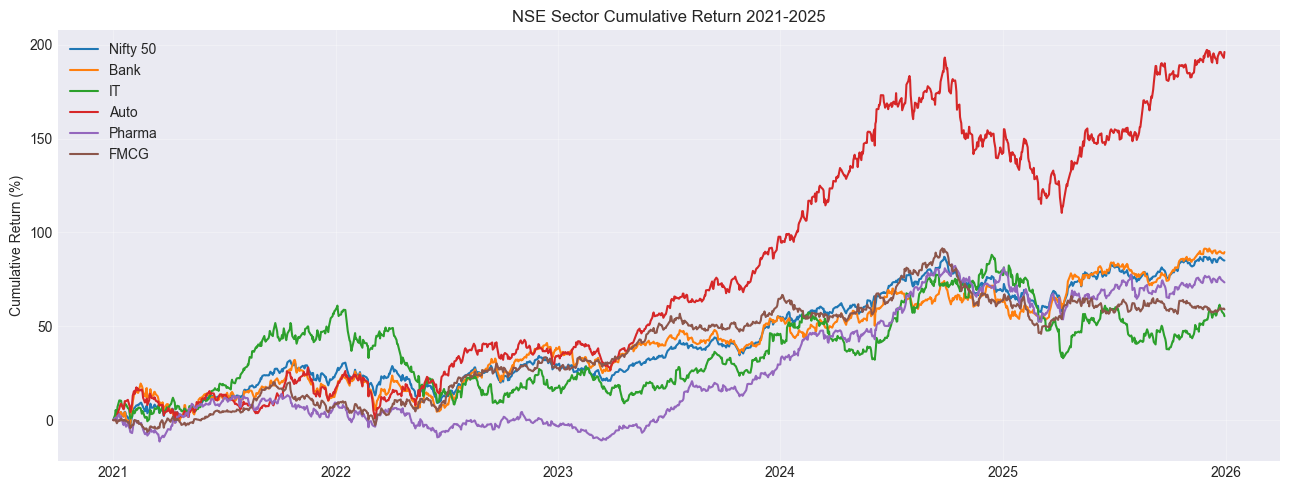

In [67]:
# ── STEP 1 : Sector index cumulative returns 2021-2025 ────────────
print('Downloading sector index data...')
idx_tickers = list(SECTOR_INDICES.values())
idx_data = build_df(idx_tickers, START_DATE, END_DATE, 'idx')
idx_data.columns = list(SECTOR_INDICES.keys())
idx_data = idx_data.ffill().bfill()

cum_ret = (idx_data / idx_data.bfill().iloc[0] - 1) * 100

print('\nFinal cumulative returns (Dec 2025):')
print(cum_ret.iloc[-1].sort_values(ascending=False).round(1).to_string())

fig, ax = plt.subplots(figsize=(13, 5))
for col in cum_ret.columns:
    ax.plot(cum_ret[col], label=col)
ax.set_title('NSE Sector Cumulative Return 2021-2025')
ax.set_ylabel('Cumulative Return (%)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task1_sector_performance.png', dpi=120, bbox_inches='tight')
plt.show()


  HDFCBANK.NS            from cache  (1235 rows)
  TCS.NS                 from cache  (1235 rows)
  SUNPHARMA.NS           from cache  (1235 rows)
  HINDUNILVR.NS          from cache  (1235 rows)
  MARUTI.NS              from cache  (1235 rows)


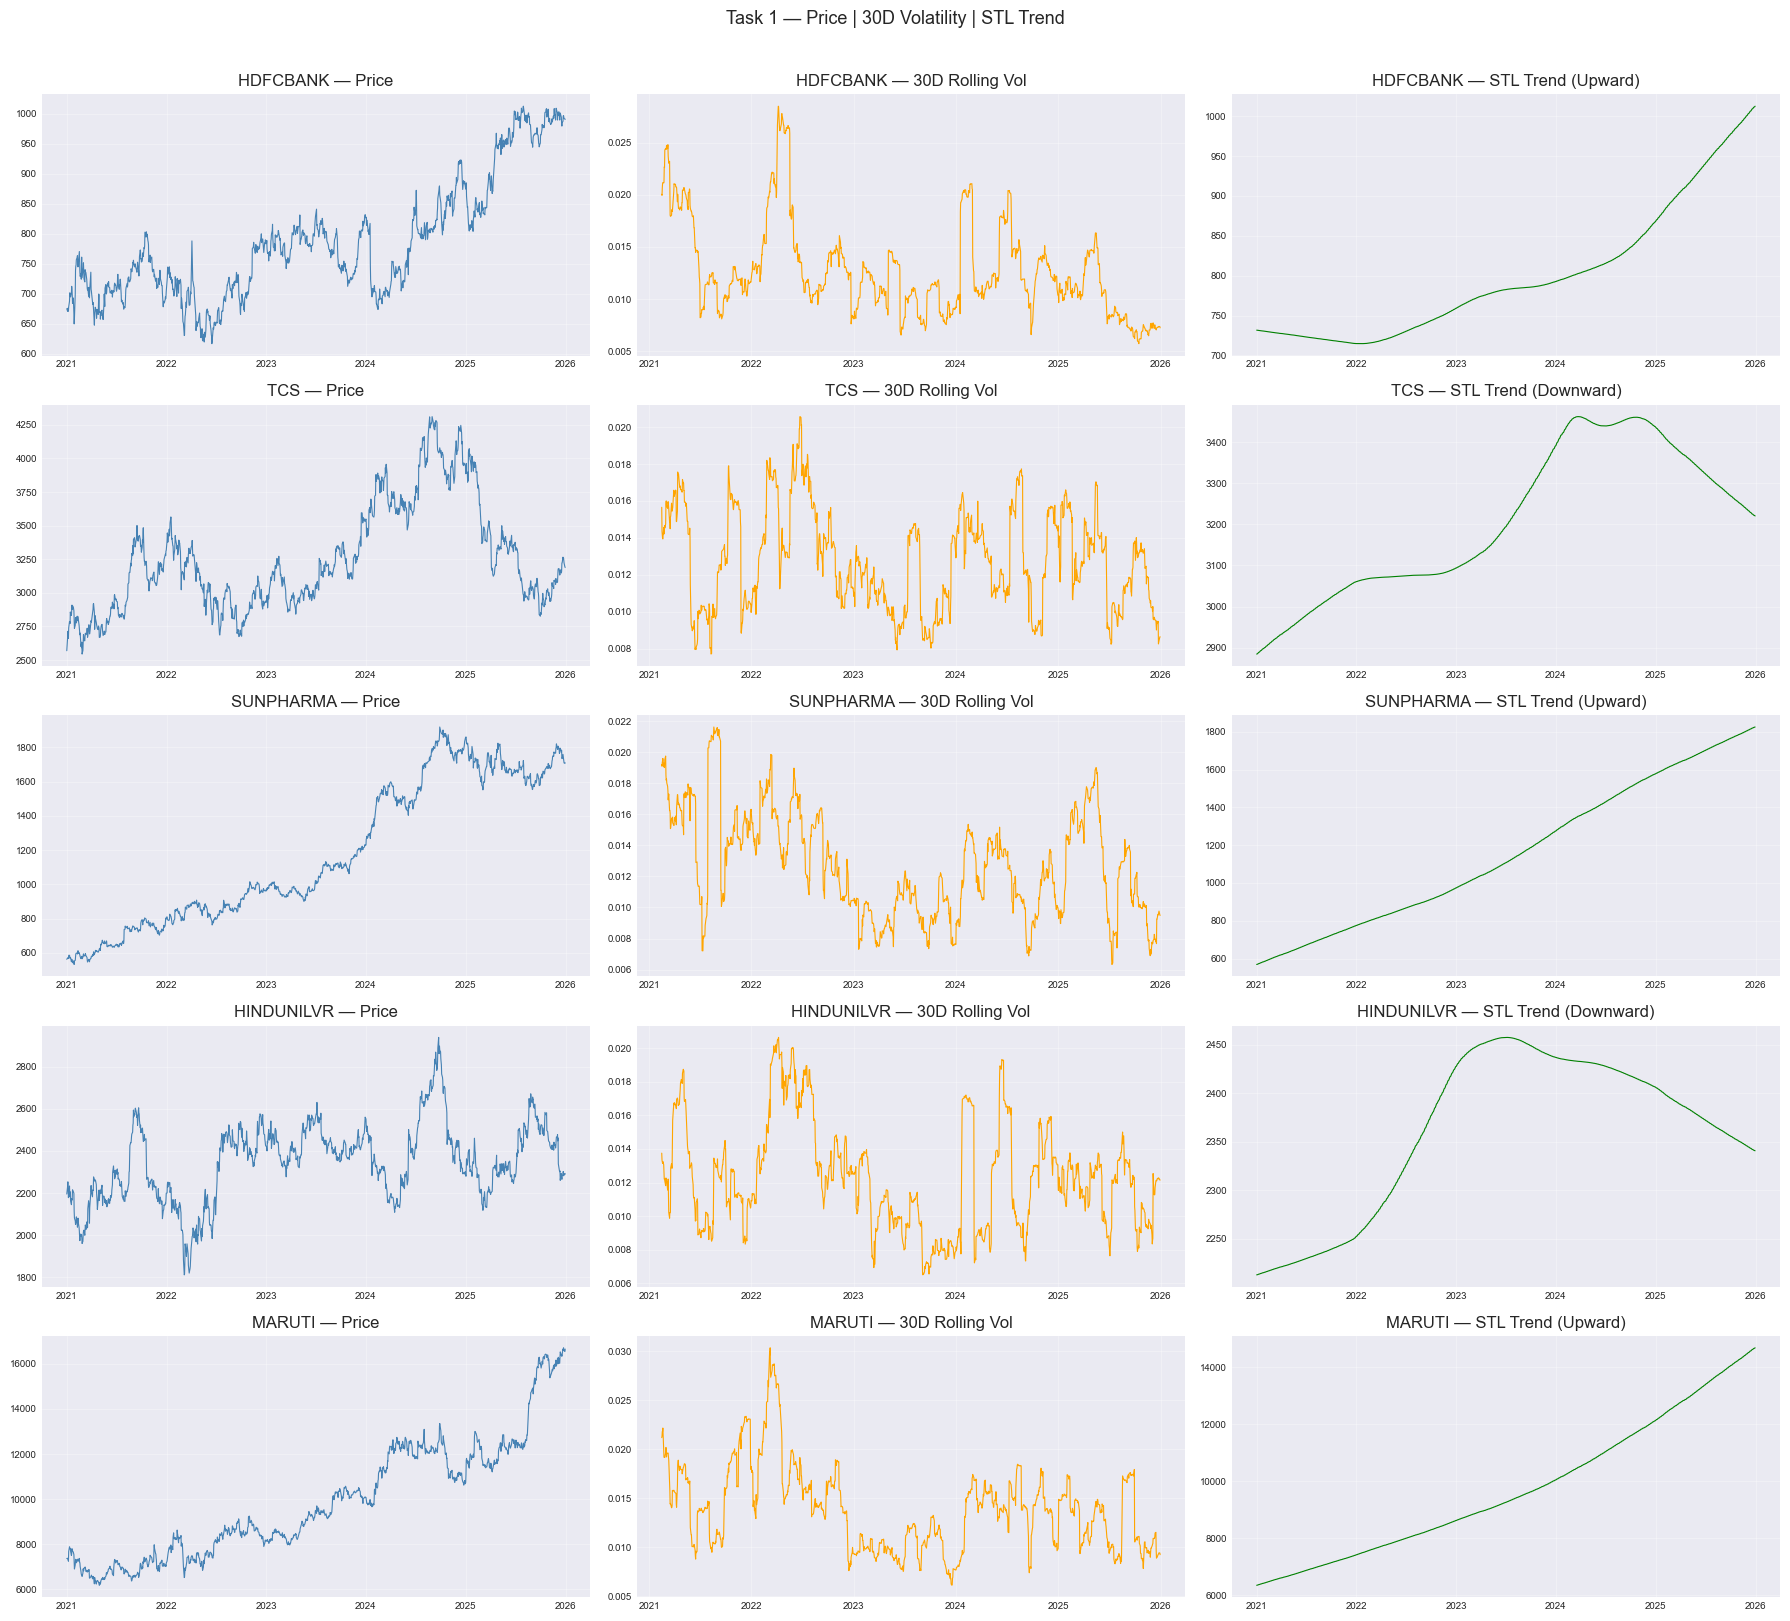


Annualised Vol (last 30 trading days):
  HDFCBANK         11.5%
  TCS              15.6%
  SUNPHARMA        12.9%
  HINDUNILVR       17.1%
  MARUTI           15.7%


In [68]:
# ── STEP 2 : Per-stock price, rolling volatility and STL trend ────
print('Downloading per-stock data...')
stock_sel = build_df(TICKERS, START_DATE, END_DATE, 'sel_stock')
stock_sel = stock_sel.ffill().bfill()[TICKERS]

fig, axes = plt.subplots(len(TICKERS), 3, figsize=(18, 16))

for i, ticker in enumerate(TICKERS):
    s = stock_sel[ticker]
    roll_std = np.log(s / s.shift(1)).rolling(30).std()
    from statsmodels.tsa.seasonal import STL as _STL
    stl_res = _STL(s, period=252, robust=True).fit()
    td = stl_res.trend
    direction = 'Upward' if td.iloc[-1] > td.iloc[-63] else 'Downward'

    axes[i, 0].plot(s, color='steelblue', linewidth=0.8)
    axes[i, 0].set_title(f'{SHORT_NAME[ticker]} — Price')
    axes[i, 1].plot(roll_std, color='orange', linewidth=0.8)
    axes[i, 1].set_title(f'{SHORT_NAME[ticker]} — 30D Rolling Vol')
    axes[i, 2].plot(td, color='green', linewidth=0.8)
    axes[i, 2].set_title(f'{SHORT_NAME[ticker]} — STL Trend ({direction})')

for ax in axes.flatten():
    ax.grid(True, alpha=0.3); ax.tick_params(labelsize=7)

plt.suptitle('Task 1 — Price | 30D Volatility | STL Trend', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('task1_stock_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

ann_vol = stock_sel.apply(lambda s: np.log(s / s.shift(1)).rolling(30).std().tail(30).mean() * np.sqrt(252) * 100)
print('\nAnnualised Vol (last 30 trading days):')
for t in TICKERS:
    print(f'  {SHORT_NAME[t]:15s}  {ann_vol[t]:.1f}%')

cand = stock_sel


---
## Task 2: Data Preprocessing

Steps:
1. Download full 5-year dataset (Jan 2021 – Dec 2025)
2. Forward-fill then backward-fill missing values
3. **Augmented Dickey-Fuller (ADF) test** for stationarity on each stock
4. First differencing for non-stationary series (used in ARIMA)
5. Train / test split: **train ≤ 30 Jun 2025**, **test ≥ 1 Jul 2025**

In [69]:
# ── Download full dataset (uses cache after first run) ────────────────
print('Task 2 — full dataset (2021-2025):')
raw  = build_df(TICKERS, START_DATE, END_DATE, 'full')
data = raw.ffill().bfill()[TICKERS].dropna()

print(f'\nDataset shape : {data.shape}')
print(f'Date range    : {data.index[0].date()}  to  {data.index[-1].date()}')
print(f'Missing values: {data.isnull().sum().sum()}')

train = data[data.index <= TRAIN_END]
test  = data[data.index >= TEST_START]

print(f'\nTrain : {train.index[0].date()} to {train.index[-1].date()}  ({len(train)} days)')
print(f'Test  : {test.index[0].date()} to {test.index[-1].date()}  ({len(test)} days)')


Task 2 — full dataset (2021-2025):
  HDFCBANK.NS            from cache  (1235 rows)
  TCS.NS                 from cache  (1235 rows)
  SUNPHARMA.NS           from cache  (1235 rows)
  HINDUNILVR.NS          from cache  (1235 rows)
  MARUTI.NS              from cache  (1235 rows)

Dataset shape : (1235, 5)
Date range    : 2021-01-01  to  2025-12-30
Missing values: 0

Train : 2021-01-01 to 2025-06-30  (1110 days)
Test  : 2025-07-01 to 2025-12-30  (125 days)


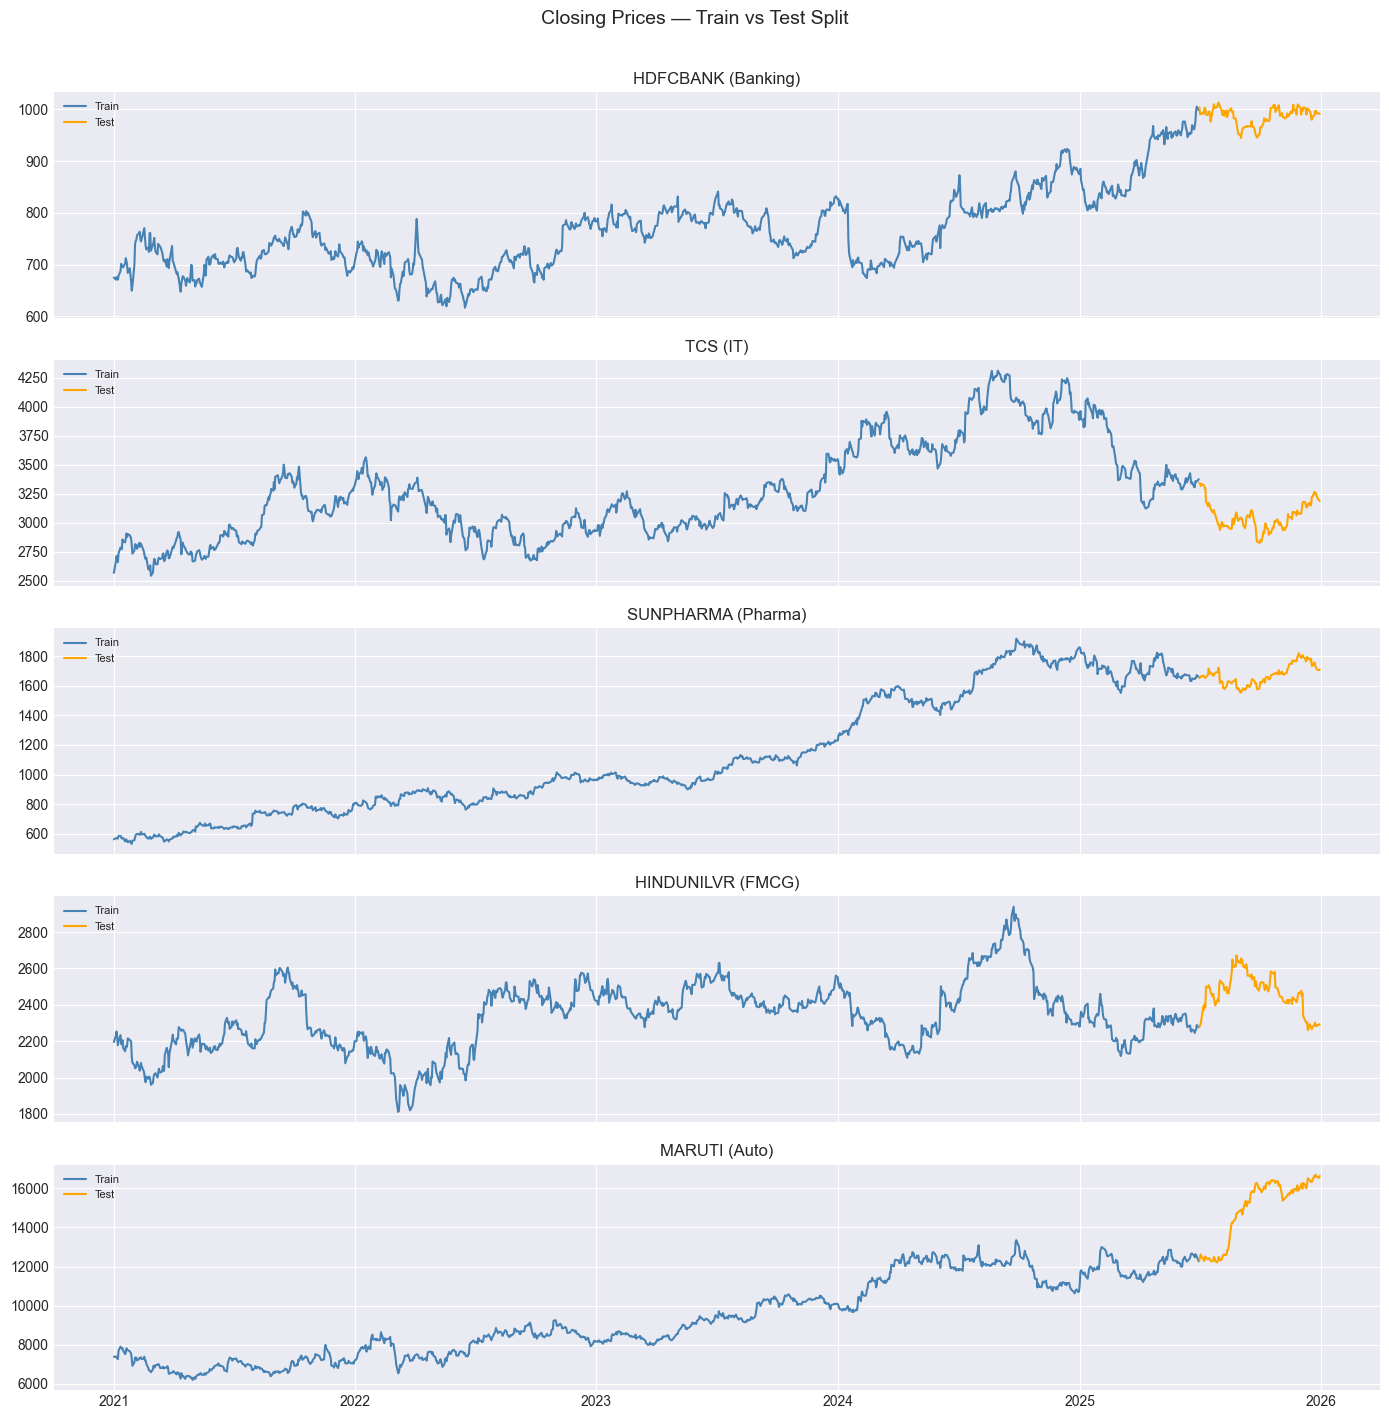

In [70]:
# ── Train / Test split chart ─────────────────────────────────────────
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 14), sharex=True)
for i, ticker in enumerate(TICKERS):
    axes[i].plot(train[ticker], label='Train', color='steelblue')
    axes[i].plot(test[ticker],  label='Test',  color='orange')
    axes[i].set_title(f'{SHORT_NAME[ticker]} ({SECTOR_MAP[ticker]})')
    axes[i].legend(loc='upper left', fontsize=8)
fig.suptitle('Closing Prices — Train vs Test Split', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('task2_train_test_split.png', dpi=120, bbox_inches='tight')
plt.show()


In [71]:
# ── Extend dataset: Jan 2026 → May 13, 2026 ───────────────────────────
# Without this, last_price = Dec 2025 and the 2-day forecast targets
# Jan 2026, not the actual StockGro trading window (May 14–15 2026).
LIVE_START = '2026-01-01'
LIVE_END   = '2026-05-13'

print(f'Extending dataset with 2026 data ({LIVE_START} → {LIVE_END})...')
live_data = build_df(TICKERS, LIVE_START, LIVE_END, 'live2026')
live_data = live_data.ffill().bfill()

# Append rows not already in data (no duplicates)
data = pd.concat([data, live_data[~live_data.index.isin(data.index)]]).sort_index()
data = data.ffill().bfill()[TICKERS].dropna()

# Re-derive test set (now Jul 2025 – May 13 2026)
test  = data[data.index >= TEST_START]
train = data[data.index <= TRAIN_END]

print(f'\nFull dataset : {data.index[0].date()} → {data.index[-1].date()}  ({len(data)} rows)')
print(f'Train        : {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} rows)')
print(f'Test         : {test.index[0].date()}  → {test.index[-1].date()}   ({len(test)} rows)')
print(f'\nLast prices (May 13, 2026) — these feed the 2-day forecast:')
for t in TICKERS:
    print(f'  {SHORT_NAME[t]:15s}  ₹{data[t].iloc[-1]:.2f}')

Extending dataset with 2026 data (2026-01-01 → 2026-05-13)...
  HDFCBANK.NS            from cache  (88 rows)
  TCS.NS                 from cache  (88 rows)
  SUNPHARMA.NS           from cache  (88 rows)
  HINDUNILVR.NS          from cache  (88 rows)
  MARUTI.NS              from cache  (88 rows)

Full dataset : 2021-01-01 → 2026-05-12  (1323 rows)
Train        : 2021-01-01 → 2025-06-30  (1110 rows)
Test         : 2025-07-01  → 2026-05-12   (213 rows)

Last prices (May 13, 2026) — these feed the 2-day forecast:
  HDFCBANK         ₹750.45
  TCS              ₹2300.30
  SUNPHARMA        ₹1845.70
  HINDUNILVR       ₹2262.00
  MARUTI           ₹13172.00


In [72]:
# ── Augmented Dickey-Fuller stationarity test ────────────────────────
def adf_test(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    stationary = result[1] < 0.05
    return {
        'Series':      name,
        'ADF Stat':    round(result[0], 4),
        'p-value':     round(result[1], 4),
        'Lags Used':   result[2],
        '1% Crit':     round(result[4]['1%'], 4),
        '5% Crit':     round(result[4]['5%'], 4),
        'Stationary':  stationary,
    }

adf_rows = []
for ticker in TICKERS:
    row_level = adf_test(train[ticker], f'{SHORT_NAME[ticker]} (Level)')
    row_diff  = adf_test(train[ticker].diff().dropna(), f'{SHORT_NAME[ticker]} (1st Diff)')
    adf_rows.extend([row_level, row_diff])

adf_df = pd.DataFrame(adf_rows)
print('=== Augmented Dickey-Fuller Test Results ===')
print(adf_df.to_string(index=False))

# First-differenced data (for ARIMA with d=1)
diff_data = data.diff().dropna()
diff_train = diff_data[diff_data.index <= TRAIN_END]
diff_test  = diff_data[diff_data.index >= TEST_START]

print('\nConclusion: All price series are non-stationary at level (p > 0.05)')
print('After 1st differencing, all series become stationary (p < 0.05)')
print('=> ARIMA will use d=1 for all stocks')

=== Augmented Dickey-Fuller Test Results ===
               Series  ADF Stat  p-value  Lags Used  1% Crit  5% Crit  Stationary
     HDFCBANK (Level)     -1.42     0.57          0    -3.44    -2.86       False
  HDFCBANK (1st Diff)    -13.19     0.00          7    -3.44    -2.86        True
          TCS (Level)     -2.18     0.22          0    -3.44    -2.86       False
       TCS (1st Diff)    -32.47     0.00          0    -3.44    -2.86        True
    SUNPHARMA (Level)     -0.66     0.86         13    -3.44    -2.86       False
 SUNPHARMA (1st Diff)     -9.75     0.00         12    -3.44    -2.86        True
   HINDUNILVR (Level)     -2.70     0.07          0    -3.44    -2.86       False
HINDUNILVR (1st Diff)    -25.00     0.00          1    -3.44    -2.86        True
       MARUTI (Level)     -0.97     0.76          1    -3.44    -2.86       False
    MARUTI (1st Diff)    -30.77     0.00          0    -3.44    -2.86        True

Conclusion: All price series are non-stationary at l

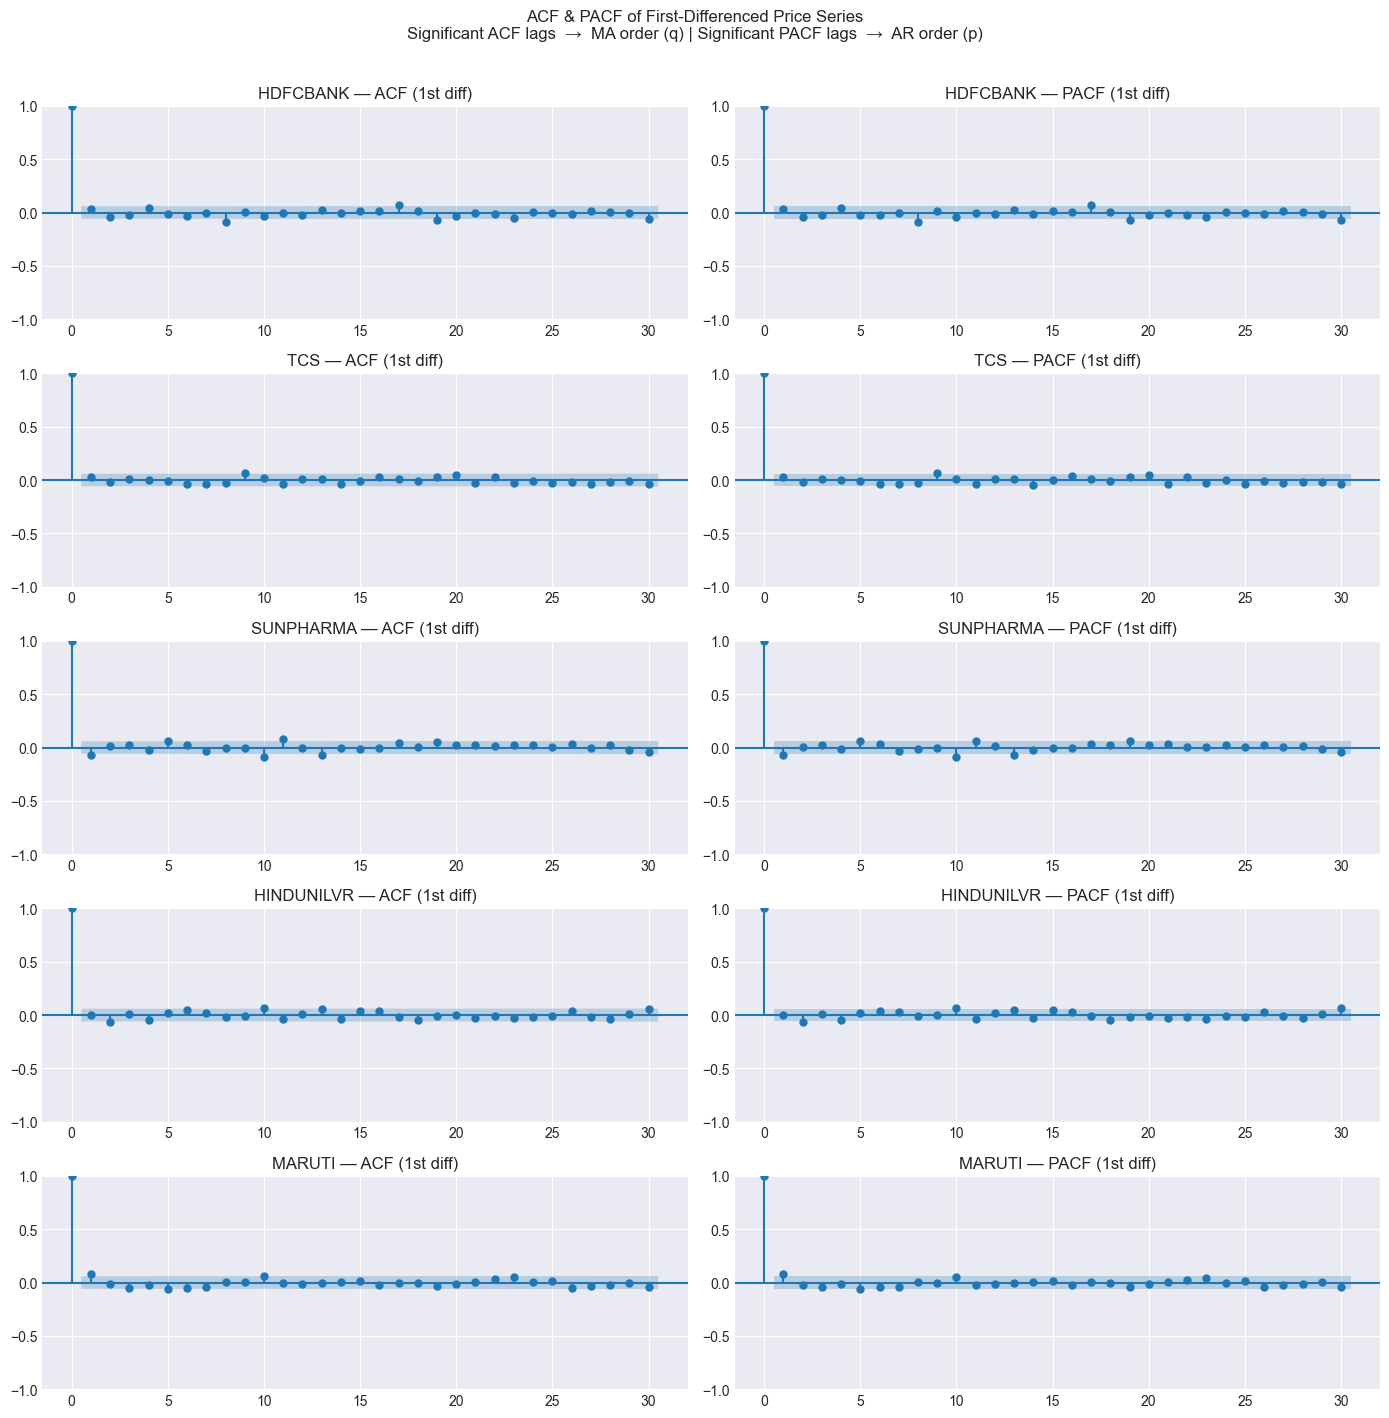

ACF/PACF plots saved — used to visually confirm ARIMA grid-search results.


In [73]:
# ── ACF / PACF — informs ARIMA (p, q) order selection ────────────────
fig, axes = plt.subplots(len(TICKERS), 2, figsize=(14, 14))

for i, ticker in enumerate(TICKERS):
    diff_series = train[ticker].diff().dropna()
    plot_acf(diff_series,  lags=30, ax=axes[i, 0],
             title=f'{SHORT_NAME[ticker]} — ACF (1st diff)')
    plot_pacf(diff_series, lags=30, ax=axes[i, 1],
              title=f'{SHORT_NAME[ticker]} — PACF (1st diff)', method='ywm')

plt.suptitle('ACF & PACF of First-Differenced Price Series\n'
             'Significant ACF lags  →  MA order (q) | Significant PACF lags  →  AR order (p)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('task2_acf_pacf.png', dpi=120, bbox_inches='tight')
plt.show()
print('ACF/PACF plots saved — used to visually confirm ARIMA grid-search results.')

---
## Task 3: Time Series Forecasting

### 3A — ARIMA
- Order (p,d,q) selected by minimising **AIC** over a grid search (p,q ∈ {0,1,2,3}, d=1)
- Residuals checked via Ljung-Box test
- Test-set (Jul–Dec 2025) forecast + 2-day ahead forecast produced

In [74]:
# ── Helper metrics ───────────────────────────────────────────────────
def mape(actual, predicted):
    a, p = np.array(actual), np.array(predicted)
    mask = a != 0
    return float(np.mean(np.abs((a[mask] - p[mask]) / a[mask])) * 100)

def rmse(actual, predicted):
    return float(np.sqrt(mean_squared_error(actual, predicted)))

def dir_accuracy(actual, predicted):
    a, p = np.array(actual), np.array(predicted)
    return float(np.mean((np.diff(a) > 0) == (np.diff(p) > 0)) * 100)

# ── ARIMA grid-search ─────────────────────────────────────────────────
def best_arima_order(series, max_pq=3, d=1):
    best_aic, best_order = np.inf, (1, 1, 1)
    for p, q in product(range(max_pq + 1), range(max_pq + 1)):
        try:
            res = ARIMA(series, order=(p, d, q)).fit()
            if res.aic < best_aic:
                best_aic, best_order = res.aic, (p, d, q)
        except Exception:
            pass
    return best_order, best_aic

arima_test_fc = {}; arima_future = {}; arima_orders = {}; arima_aic = {}

for ticker in TICKERS:
    print(f'[ARIMA] {SHORT_NAME[ticker]}', end='  ')
    order, aic = best_arima_order(train[ticker])
    arima_orders[ticker] = order; arima_aic[ticker] = aic
    print(f'order={order}  AIC={aic:.1f}')
    model_full = ARIMA(train[ticker], order=order).fit()
    n_fc = len(test) + 2
    fc   = model_full.forecast(steps=n_fc)
    arima_test_fc[ticker] = pd.Series(fc.values[:len(test)], index=test.index[:len(fc)])
    arima_future[ticker]  = fc.values[len(test): len(test) + 2]

print('\nARIMA fitting done.')


[ARIMA] HDFCBANK  order=(2, 1, 2)  AIC=8354.5
[ARIMA] TCS  order=(0, 1, 0)  AIC=11531.4
[ARIMA] SUNPHARMA  order=(2, 1, 2)  AIC=9179.6
[ARIMA] HINDUNILVR  order=(0, 1, 2)  AIC=10650.0
[ARIMA] MARUTI  order=(2, 1, 1)  AIC=14049.8

ARIMA fitting done.


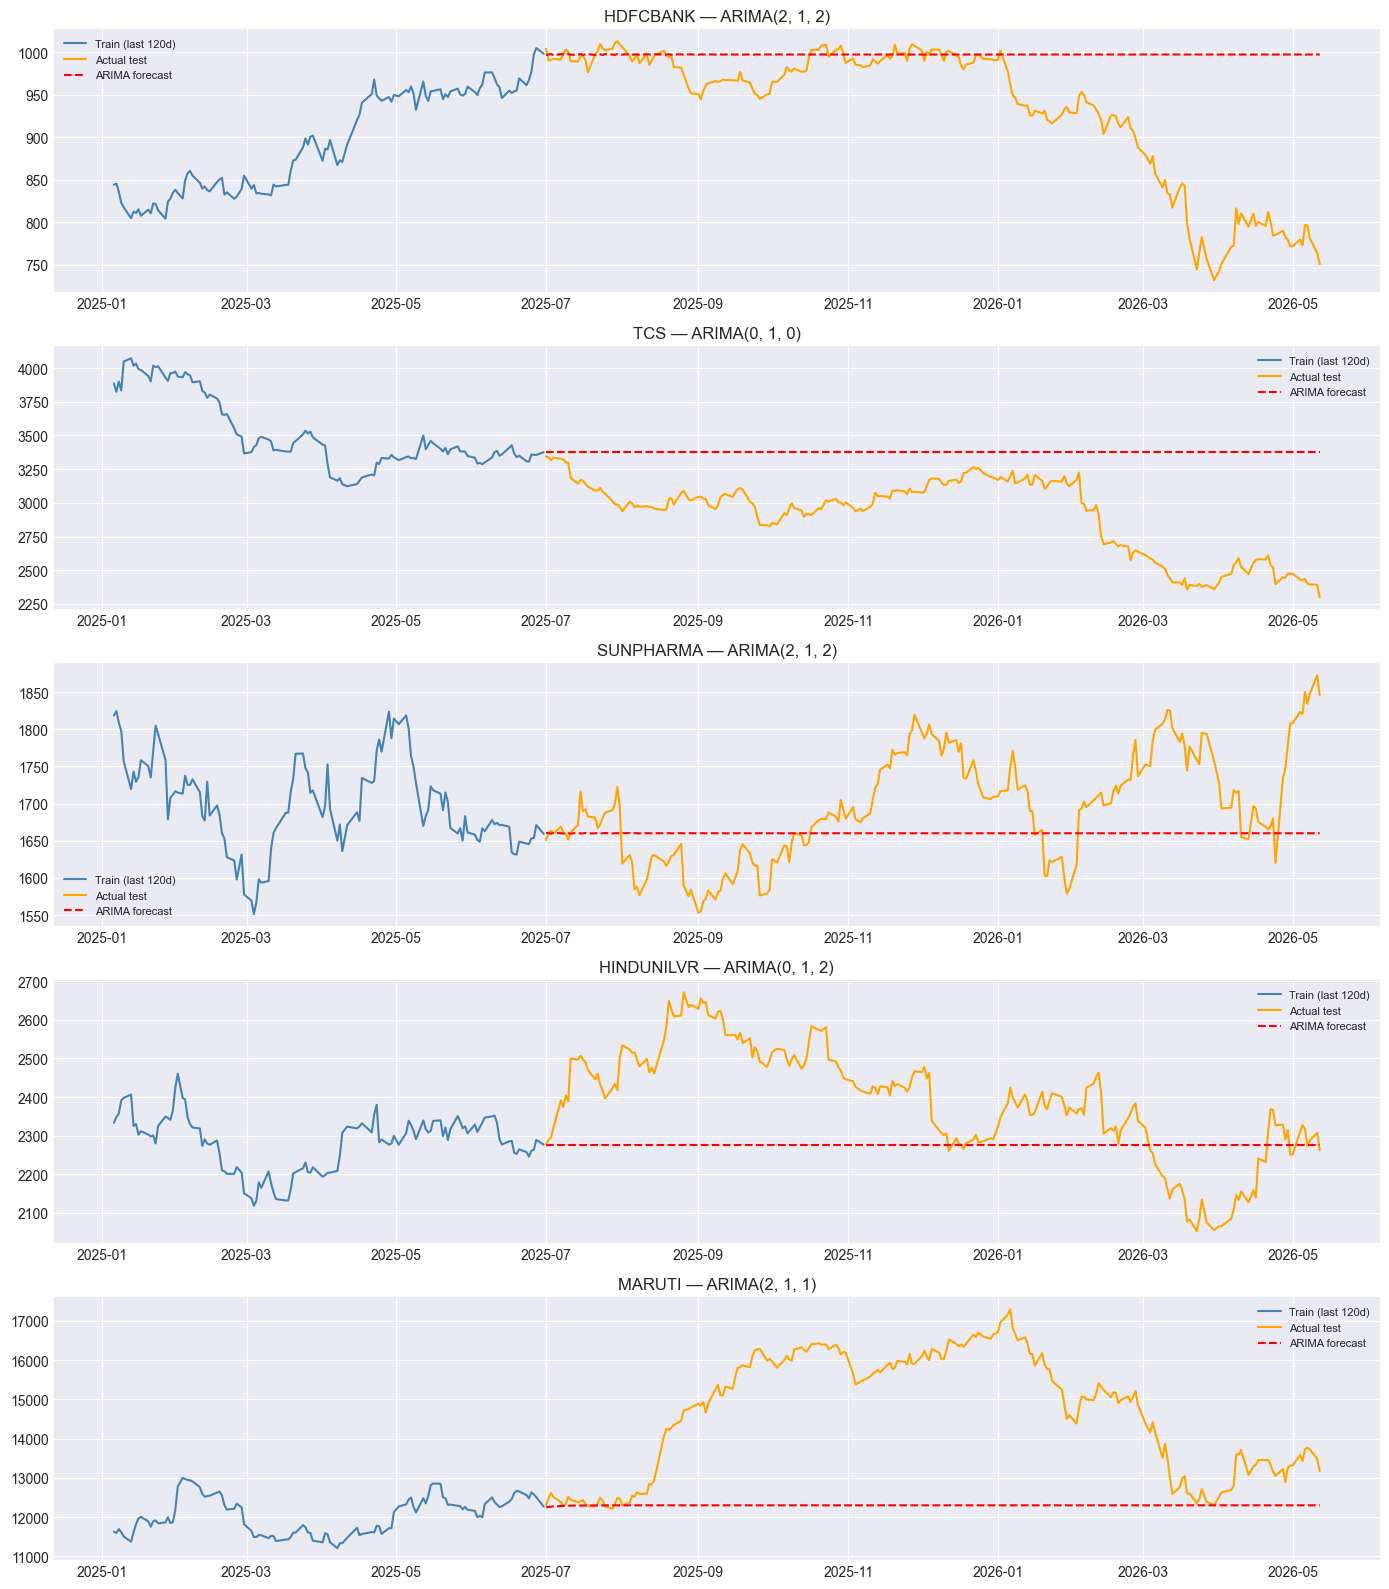

In [75]:
# ── ARIMA forecast plot ───────────────────────────────────────────────
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 16), sharex=False)
for i, ticker in enumerate(TICKERS):
    axes[i].plot(train[ticker].tail(120), color='steelblue', label='Train (last 120d)')
    axes[i].plot(test[ticker],            color='orange',    label='Actual test')
    axes[i].plot(arima_test_fc[ticker],   color='red', linestyle='--', label='ARIMA forecast')
    axes[i].set_title(f'{SHORT_NAME[ticker]} — ARIMA{arima_orders[ticker]}')
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.savefig('task3_arima.png', dpi=120, bbox_inches='tight')
plt.show()


### 3B — Facebook Prophet
- Additive model with yearly + weekly seasonality
- `changepoint_prior_scale=0.05` to reduce over-fitting to recent price spikes
- Produces forecast with 95% confidence interval

In [76]:
prophet_test_fc = {}; prophet_future = {}; prophet_ci = {}

if not PROPHET_AVAILABLE:
    print('Prophet not installed — skipping 3B.')
else:
    for ticker in TICKERS:
        print(f'[Prophet] {SHORT_NAME[ticker]}...')
        df_p = pd.DataFrame({'ds': train.index, 'y': train[ticker].values})
        m = Prophet(
            yearly_seasonality=True, weekly_seasonality=True,
            daily_seasonality=False, changepoint_prior_scale=0.05,
            seasonality_prior_scale=10.0,
        )
        m.fit(df_p)
        future_df = m.make_future_dataframe(periods=len(test) + 2, freq='B')
        fc = m.predict(future_df)
        fc_indexed = fc.set_index('ds')['yhat']
        prophet_test_fc[ticker] = fc_indexed.reindex(test.index, method='nearest')
        last2 = fc.tail(2)
        prophet_future[ticker] = last2['yhat'].values
        prophet_ci[ticker] = list(zip(last2['yhat_lower'].values, last2['yhat_upper'].values))
    print('\nProphet done.')


13:53:34 - cmdstanpy - INFO - Chain [1] start processing


[Prophet] HDFCBANK...


13:53:35 - cmdstanpy - INFO - Chain [1] done processing
13:53:35 - cmdstanpy - INFO - Chain [1] start processing


[Prophet] TCS...


13:53:35 - cmdstanpy - INFO - Chain [1] done processing
13:53:35 - cmdstanpy - INFO - Chain [1] start processing


...

[Prophet] HINDUNILVR...


13:53:36 - cmdstanpy - INFO - Chain [1] done processing
13:53:37 - cmdstanpy - INFO - Chain [1] start processing


[Prophet] MARUTI...


13:53:37 - cmdstanpy - INFO - Chain [1] done processing



Prophet done.


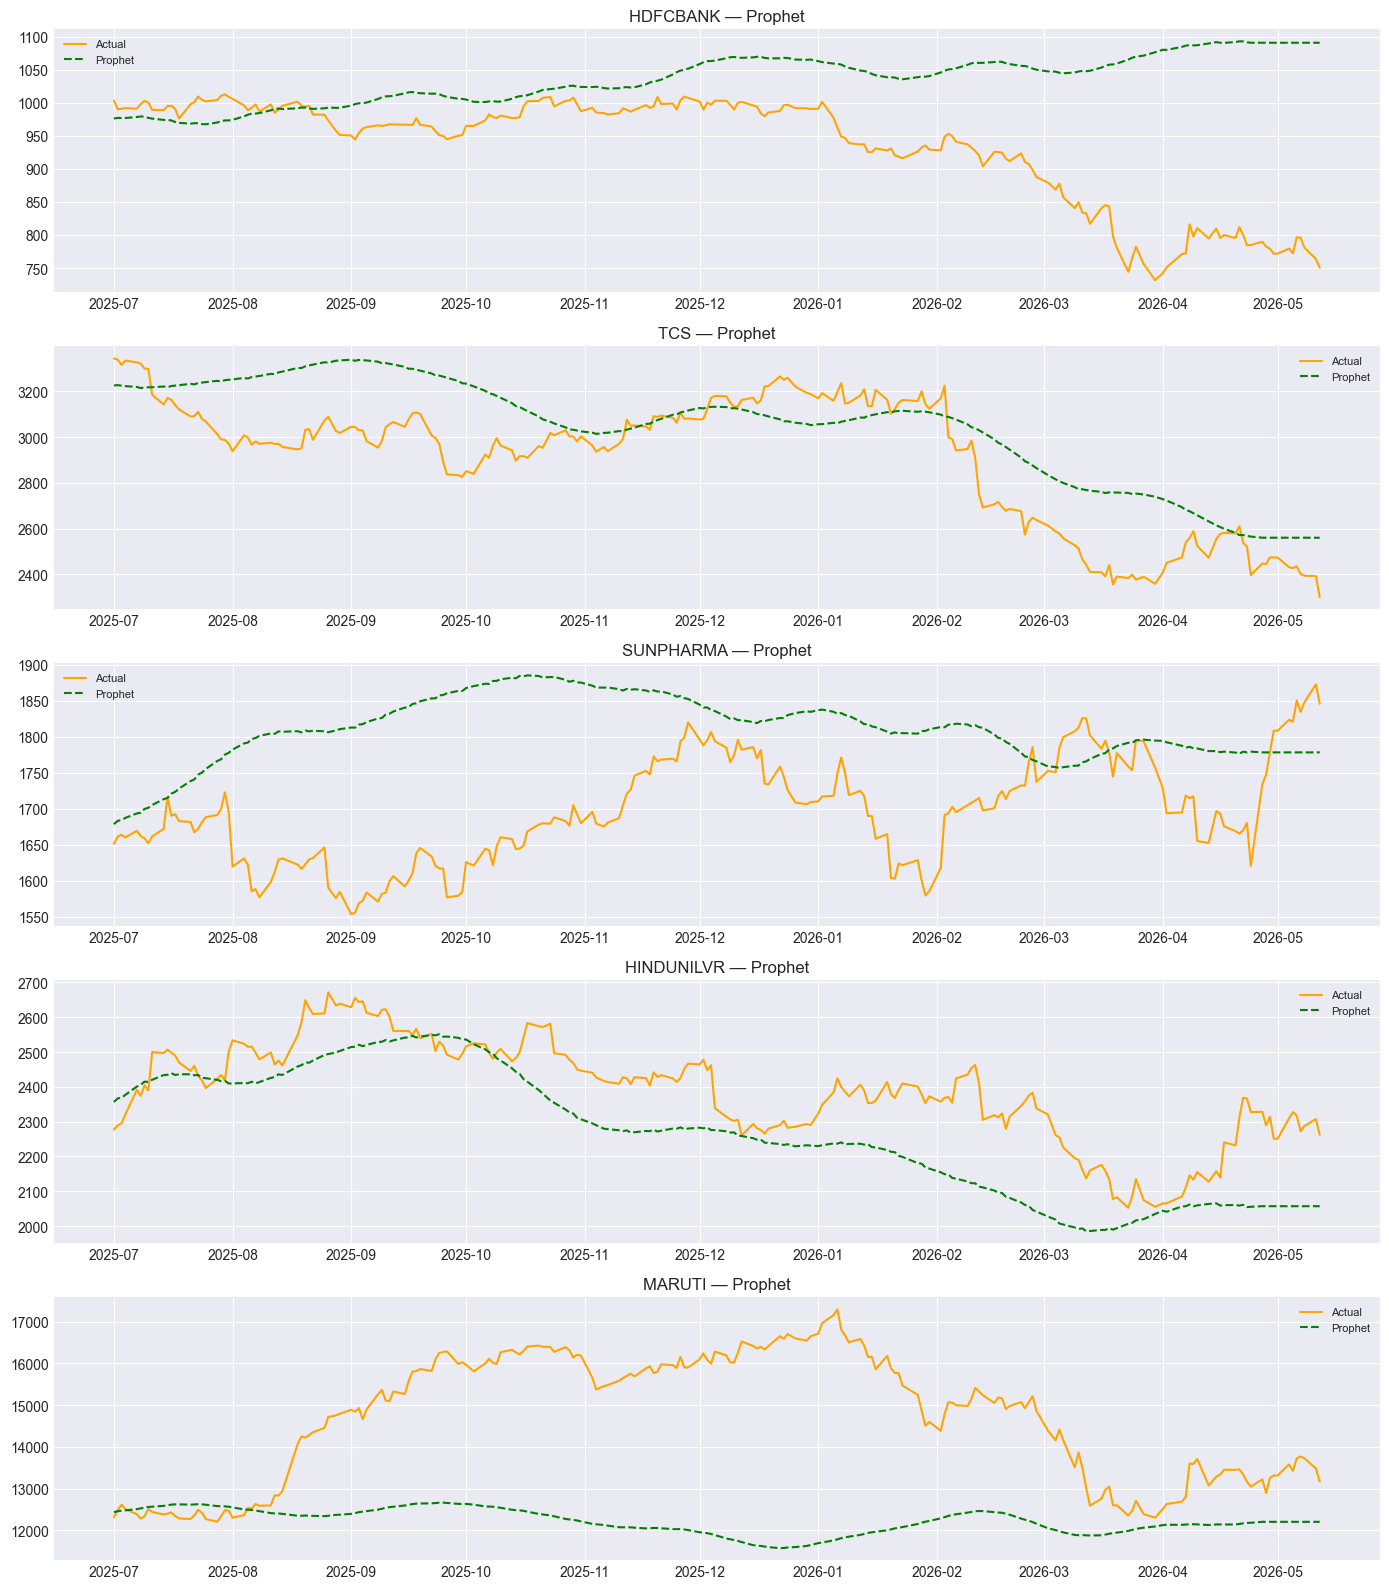

In [77]:
# ── Prophet forecast plot ────────────────────────────────────────────
if PROPHET_AVAILABLE and prophet_test_fc:
    fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 16), sharex=False)
    for i, ticker in enumerate(TICKERS):
        axes[i].plot(test[ticker],            color='orange', label='Actual')
        axes[i].plot(prophet_test_fc[ticker], color='green',  linestyle='--', label='Prophet')
        axes[i].set_title(f'{SHORT_NAME[ticker]} — Prophet')
        axes[i].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('task3_prophet.png', dpi=120, bbox_inches='tight')
    plt.show()


In [78]:
# ═══════════════════════════════════════════════════════════════════════
# 3C — Holt-Winters Exponential Smoothing (Additive Trend + Seasonal)
# ═══════════════════════════════════════════════════════════════════════
hw_test_fc = {}; hw_future = {}

for ticker in TICKERS:
    print(f'[Holt-Winters] {SHORT_NAME[ticker]}...', end=' ')
    try:
        hw_model = ExponentialSmoothing(
            train[ticker], trend='add', seasonal='add',
            seasonal_periods=252, initialization_method='estimated',
        )
        hw_fit = hw_model.fit(optimized=True, remove_bias=True)
        n_fc   = len(test) + 2
        fc     = hw_fit.forecast(n_fc)
        hw_test_fc[ticker] = pd.Series(fc.values[:len(test)], index=test.index[:len(test)])
        hw_future[ticker]  = fc.values[len(test): len(test) + 2]
        print('OK')
    except Exception as exc:
        print(f'FAILED ({exc}) — using ARIMA fallback')
        hw_test_fc[ticker] = arima_test_fc[ticker]
        hw_future[ticker]  = arima_future[ticker]

print('\nHolt-Winters done.')


[Holt-Winters] HDFCBANK... OK
[Holt-Winters] TCS... OK
[Holt-Winters] SUNPHARMA... OK
[Holt-Winters] HINDUNILVR... OK
[Holt-Winters] MARUTI... OK

Holt-Winters done.


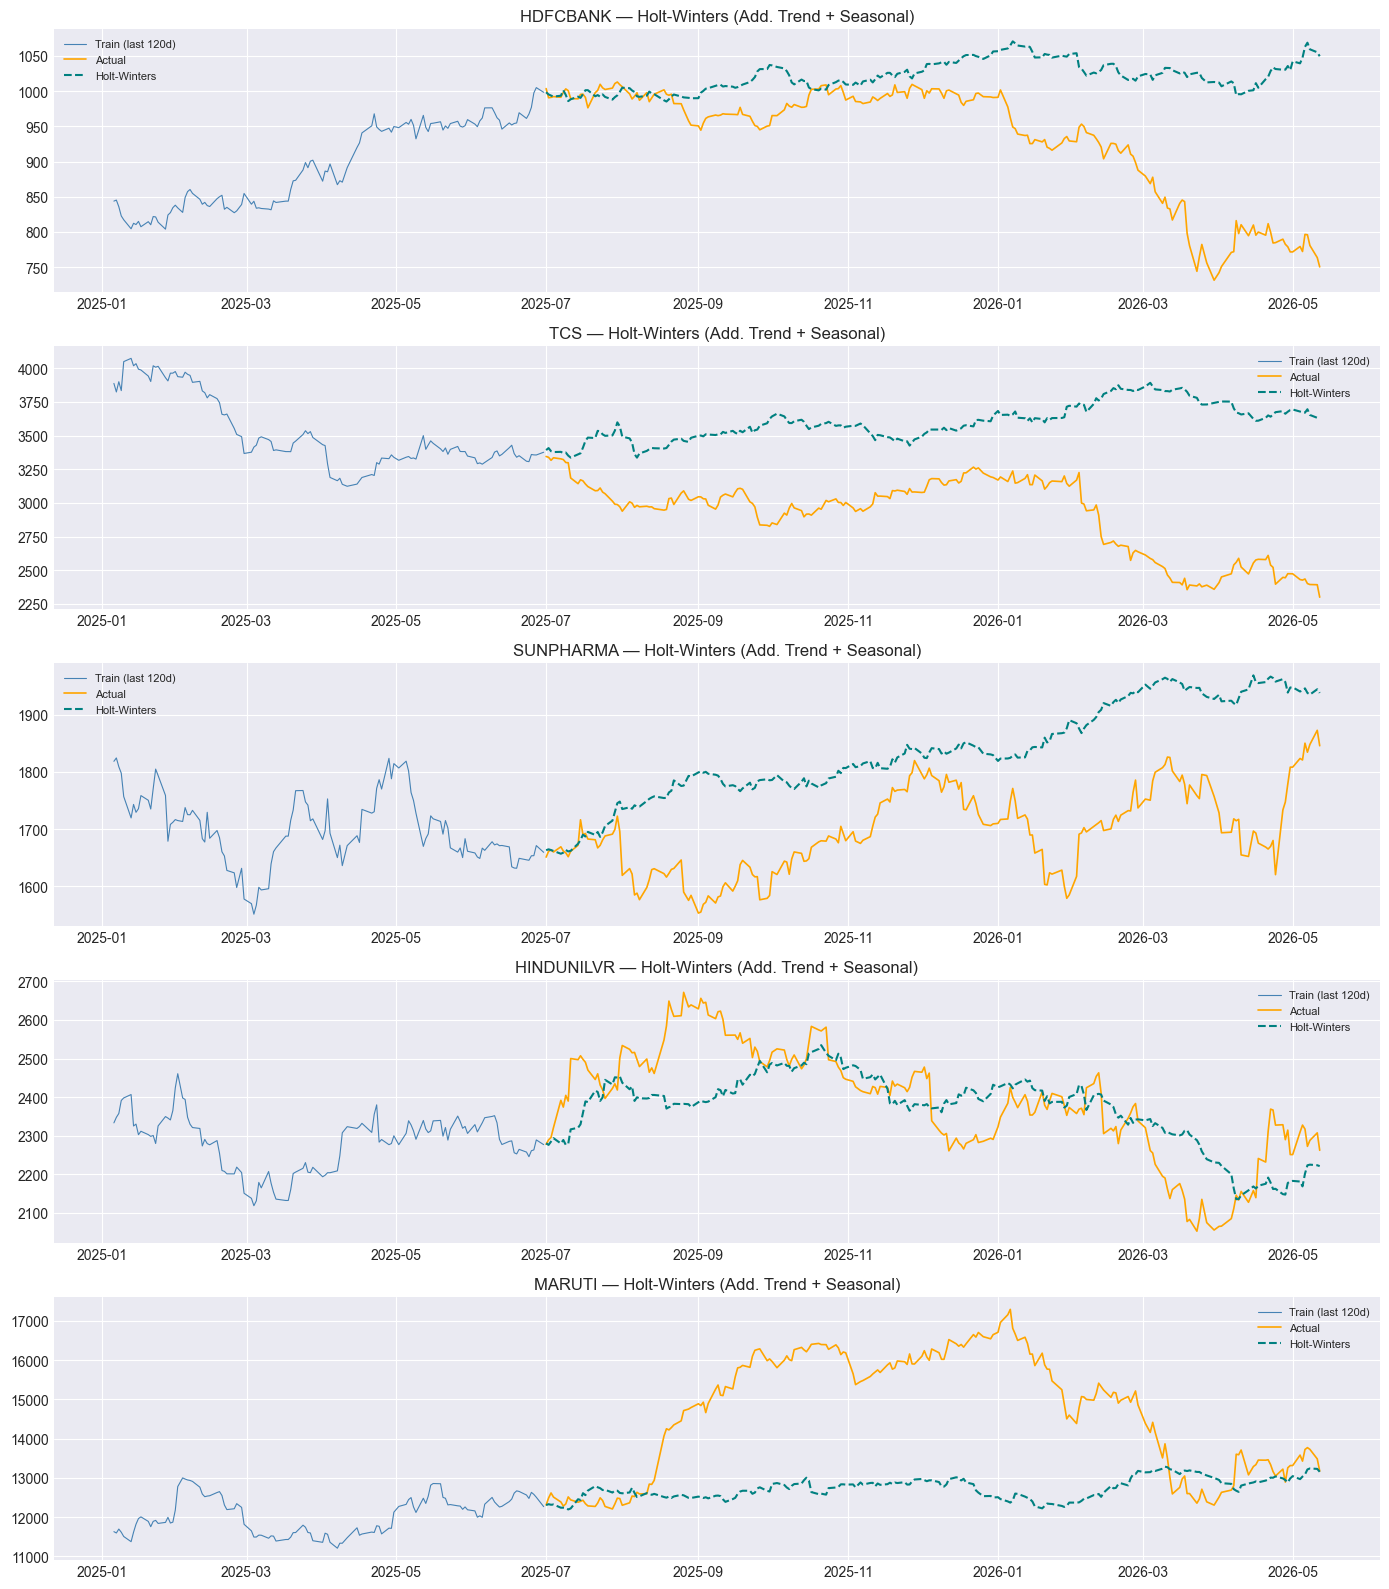

In [79]:
# ── Holt-Winters forecast plot ────────────────────────────────────────
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 16), sharex=False)
for i, ticker in enumerate(TICKERS):
    axes[i].plot(train[ticker].tail(120), color='steelblue', label='Train (last 120d)', linewidth=0.8)
    axes[i].plot(test[ticker],            color='orange',    label='Actual',            linewidth=1.2)
    axes[i].plot(hw_test_fc[ticker],      color='teal',      label='Holt-Winters',      linestyle='--')
    axes[i].set_title(f'{SHORT_NAME[ticker]} — Holt-Winters (Add. Trend + Seasonal)')
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.savefig('task3_holtwinters.png', dpi=120, bbox_inches='tight')
plt.show()


### 3C — LSTM (Long Short-Term Memory)
- Sequence length: 60 trading days
- Architecture: LSTM(50) → Dropout(0.2) → LSTM(50) → Dropout(0.2) → Dense(25) → Dense(1)
- Input features are MinMax-scaled; outputs inverse-transformed back to price space
- Rolling one-step prediction on the test set for fair evaluation

In [80]:
SEQ_LEN = 60

def build_lstm():
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(SEQ_LEN, 1)),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25), Dense(1),
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def make_sequences(arr, seq_len):
    X, y = [], []
    for i in range(seq_len, len(arr)):
        X.append(arr[i - seq_len:i, 0]); y.append(arr[i, 0])
    return np.array(X)[..., np.newaxis], np.array(y)

lstm_test_fc = {}; lstm_future = {}; lstm_scalers = {}

for ticker in TICKERS:
    print(f'[LSTM] {SHORT_NAME[ticker]}...')
    scaler   = MinMaxScaler()
    train_sc = scaler.fit_transform(train[[ticker]])
    test_sc  = scaler.transform(test[[ticker]])
    full_sc  = np.vstack([train_sc, test_sc])
    X_tr, y_tr = make_sequences(train_sc, SEQ_LEN)
    mdl = build_lstm()
    es  = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    mdl.fit(X_tr, y_tr, epochs=80, batch_size=32,
            validation_split=0.1, callbacks=[es], verbose=0)
    preds_sc = []
    window = train_sc[-SEQ_LEN:].copy()
    for i in range(len(test)):
        x = window[-SEQ_LEN:].reshape(1, SEQ_LEN, 1)
        p = mdl.predict(x, verbose=0)[0, 0]
        preds_sc.append(p)
        window = np.vstack([window, [[test_sc[i, 0]]]])
    preds = scaler.inverse_transform(np.array(preds_sc).reshape(-1, 1)).flatten()
    lstm_test_fc[ticker] = pd.Series(preds, index=test.index)
    window2 = full_sc[-SEQ_LEN:].copy()
    future_preds = []
    for _ in range(2):
        x = window2[-SEQ_LEN:].reshape(1, SEQ_LEN, 1)
        p = mdl.predict(x, verbose=0)[0, 0]
        future_preds.append(p)
        window2 = np.vstack([window2, [[p]]])
    lstm_future[ticker]  = scaler.inverse_transform(np.array(future_preds).reshape(-1,1)).flatten()
    lstm_scalers[ticker] = scaler

print('\nLSTM training done.')


[LSTM] HDFCBANK...
[LSTM] TCS...
[LSTM] SUNPHARMA...
[LSTM] HINDUNILVR...
[LSTM] MARUTI...

LSTM training done.


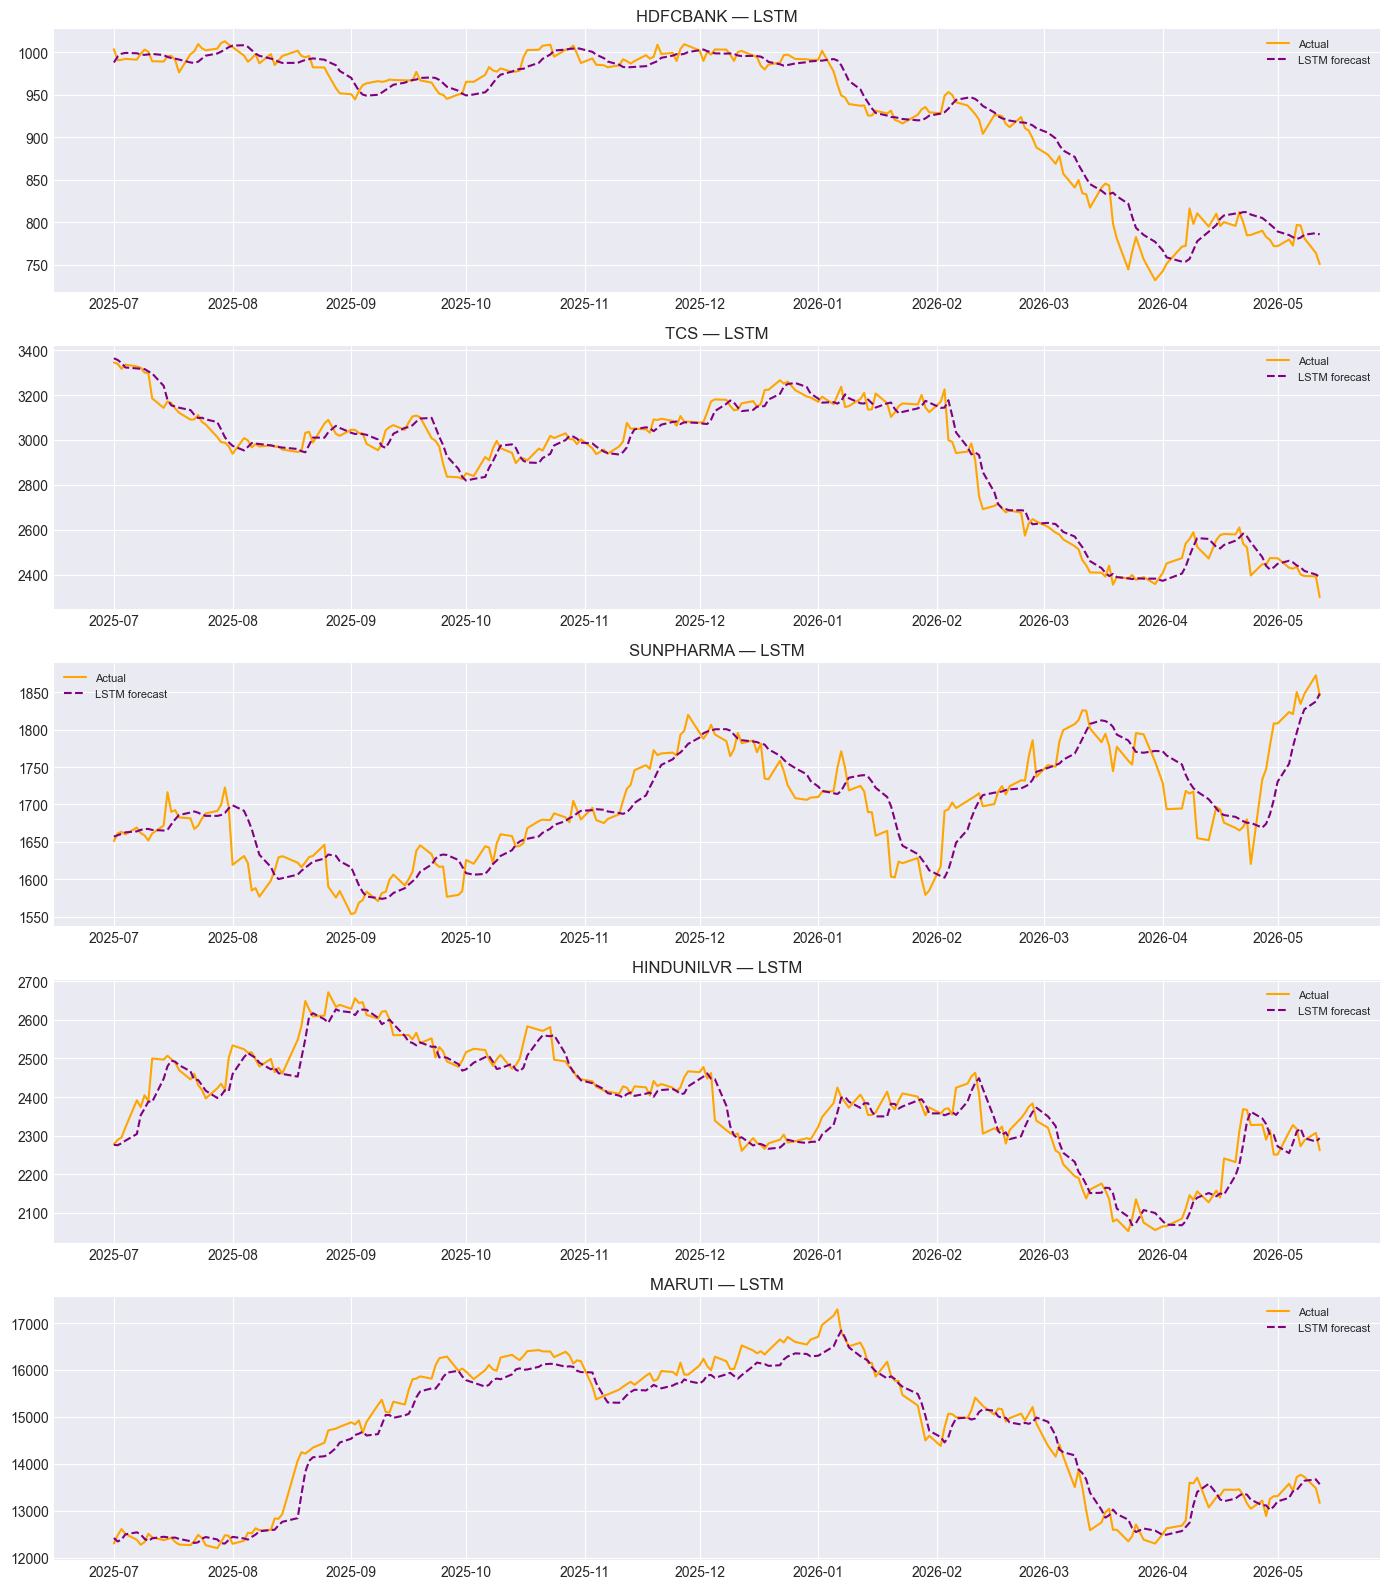

In [81]:
# ── LSTM forecast plot ───────────────────────────────────────────────
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 16))
for i, ticker in enumerate(TICKERS):
    axes[i].plot(test[ticker],         color='orange', label='Actual')
    axes[i].plot(lstm_test_fc[ticker], color='purple', linestyle='--', label='LSTM forecast')
    axes[i].set_title(f'{SHORT_NAME[ticker]} — LSTM')
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.savefig('task3_lstm.png', dpi=120, bbox_inches='tight')
plt.show()


In [82]:
# ═══════════════════════════════════════════════════════════════════════
# 3E — Ensemble Forecast: simple mean of all models
# ═══════════════════════════════════════════════════════════════════════
ensemble_test_fc = {}; ensemble_future = {}

for ticker in TICKERS:
    test_preds   = [arima_test_fc[ticker].values[:len(test)],
                    hw_test_fc[ticker].values[:len(test)],
                    lstm_test_fc[ticker].values[:len(test)]]
    future_preds = [arima_future[ticker], hw_future[ticker], lstm_future[ticker]]
    if PROPHET_AVAILABLE and ticker in prophet_test_fc:
        test_preds.append(prophet_test_fc[ticker].values[:len(test)])
        future_preds.append(prophet_future[ticker])
    n = min(len(a) for a in test_preds)
    ensemble_test_fc[ticker] = pd.Series(
        np.mean([a[:n] for a in test_preds], axis=0), index=test.index[:n])
    ensemble_future[ticker]  = np.mean(future_preds, axis=0)

models_used = ['ARIMA', 'Holt-Winters', 'LSTM'] + (['Prophet'] if PROPHET_AVAILABLE else [])
print(f'Ensemble = mean of: {", ".join(models_used)}')


Ensemble = mean of: ARIMA, Holt-Winters, LSTM, Prophet


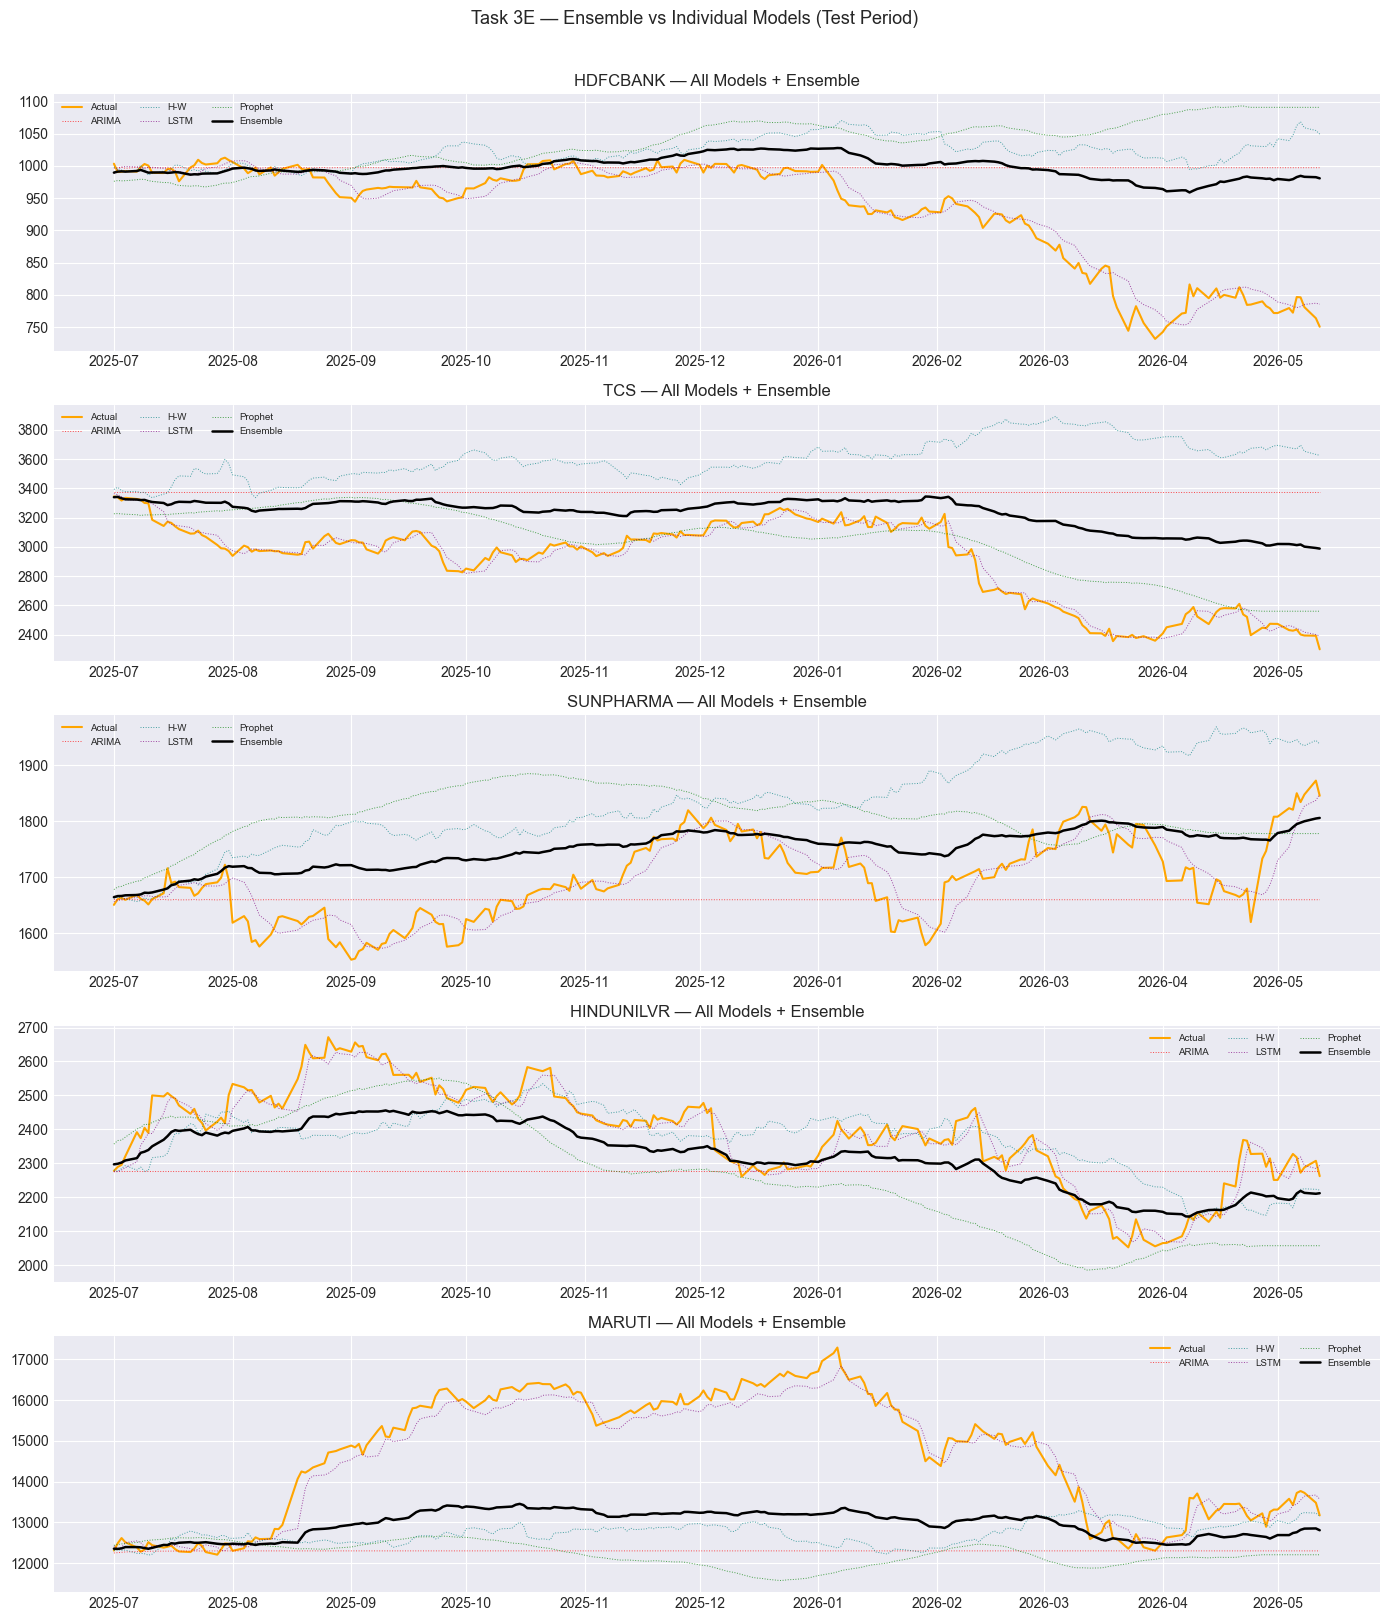

In [83]:
# ── Ensemble vs individual models plot ────────────────────────────────
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 16), sharex=False)
for i, ticker in enumerate(TICKERS):
    axes[i].plot(test[ticker],             color='orange', linewidth=1.5, label='Actual')
    axes[i].plot(arima_test_fc[ticker],    color='red',    linewidth=0.7, linestyle=':', alpha=0.7, label='ARIMA')
    axes[i].plot(hw_test_fc[ticker],       color='teal',   linewidth=0.7, linestyle=':', alpha=0.7, label='H-W')
    axes[i].plot(lstm_test_fc[ticker],     color='purple', linewidth=0.7, linestyle=':', alpha=0.7, label='LSTM')
    if PROPHET_AVAILABLE and ticker in prophet_test_fc:
        axes[i].plot(prophet_test_fc[ticker], color='green', linewidth=0.7, linestyle=':', alpha=0.7, label='Prophet')
    axes[i].plot(ensemble_test_fc[ticker], color='black',  linewidth=1.8, label='Ensemble')
    axes[i].set_title(f'{SHORT_NAME[ticker]} — All Models + Ensemble')
    axes[i].legend(fontsize=7, ncol=3)
plt.suptitle('Task 3E — Ensemble vs Individual Models (Test Period)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('task3_ensemble.png', dpi=120, bbox_inches='tight')
plt.show()


In [84]:
# ── Compute test-set metrics for all models (incl. Holt-Winters + Ensemble) ──
metrics = {}

model_fc_list = [
    ('ARIMA',        arima_test_fc),
    ('Holt-Winters', hw_test_fc),
    ('LSTM',         lstm_test_fc),
    ('Ensemble',     ensemble_test_fc),
]
if PROPHET_AVAILABLE:
    model_fc_list.insert(2, ('Prophet', prophet_test_fc))

for ticker in TICKERS:
    actual = test[ticker].values
    row = {}
    for model_name, fc_dict in model_fc_list:
        if ticker not in fc_dict:
            continue
        fc_vals = fc_dict[ticker].values[:len(actual)]
        n = len(fc_vals)
        row[model_name] = {
            'MAPE (%)':    round(mape(actual[:n], fc_vals), 2),
            'RMSE (₹)':    round(rmse(actual[:n], fc_vals), 2),
            'Dir Acc (%)': round(dir_accuracy(actual[:n], fc_vals), 1),
        }
    metrics[ticker] = row

# Print summary
print('=== Test-Set Metrics (Jul–Dec 2025) ===\n')
for ticker in TICKERS:
    print(f'{SHORT_NAME[ticker]}:')
    for m_name, m_vals in metrics[ticker].items():
        print(f'  {m_name:14s}  MAPE={m_vals["MAPE (%)"]:.2f}%  '
              f'RMSE=₹{m_vals["RMSE (₹)"]:.0f}  DA={m_vals["Dir Acc (%)"]:.1f}%')
    print()

=== Test-Set Metrics (Jul–Dec 2025) ===

HDFCBANK:
  ARIMA           MAPE=7.76%  RMSE=₹101  DA=46.7%
  Holt-Winters    MAPE=10.35%  RMSE=₹122  DA=41.0%
  Prophet         MAPE=12.42%  RMSE=₹146  DA=58.0%
  LSTM            MAPE=1.37%  RMSE=₹16  DA=52.8%
  Ensemble        MAPE=7.71%  RMSE=₹94  DA=45.8%

TCS:
  ARIMA           MAPE=16.92%  RMSE=₹536  DA=58.0%
  Holt-Winters    MAPE=24.90%  RMSE=₹778  DA=49.5%
  Prophet         MAPE=6.05%  RMSE=₹207  DA=54.7%
  LSTM            MAPE=1.27%  RMSE=₹48  DA=51.9%
  Ensemble        MAPE=11.68%  RMSE=₹370  DA=50.0%

SUNPHARMA:
  ARIMA           MAPE=3.79%  RMSE=₹80  DA=49.1%
  Holt-Winters    MAPE=8.23%  RMSE=₹157  DA=50.9%
  Prophet         MAPE=7.33%  RMSE=₹144  DA=52.8%
  LSTM            MAPE=1.49%  RMSE=₹33  DA=52.8%
  Ensemble        MAPE=3.70%  RMSE=₹76  DA=51.4%

HINDUNILVR:
  ARIMA           MAPE=6.26%  RMSE=₹181  DA=53.8%
  Holt-Winters    MAPE=3.62%  RMSE=₹111  DA=46.7%
  Prophet         MAPE=5.33%  RMSE=₹153  DA=55.7%
  LSTM            M

---
## Task 4: Volatility and Trend Analysis

- **Log returns** computed as `ln(P_t / P_{t-1})`
- **Rolling 30-day annualised volatility** as a baseline risk measure
- **GARCH(1,1)** fits time-varying conditional volatility and produces a 2-day volatility forecast
- **STL decomposition** (period=252) decomposes each price series into Trend, Seasonality, Residual

Annualised Volatility (last 30 trading days of 2025):
  HDFCBANK         31.98%
  TCS              29.92%
  SUNPHARMA        30.75%
  HINDUNILVR       27.98%
  MARUTI           31.37%


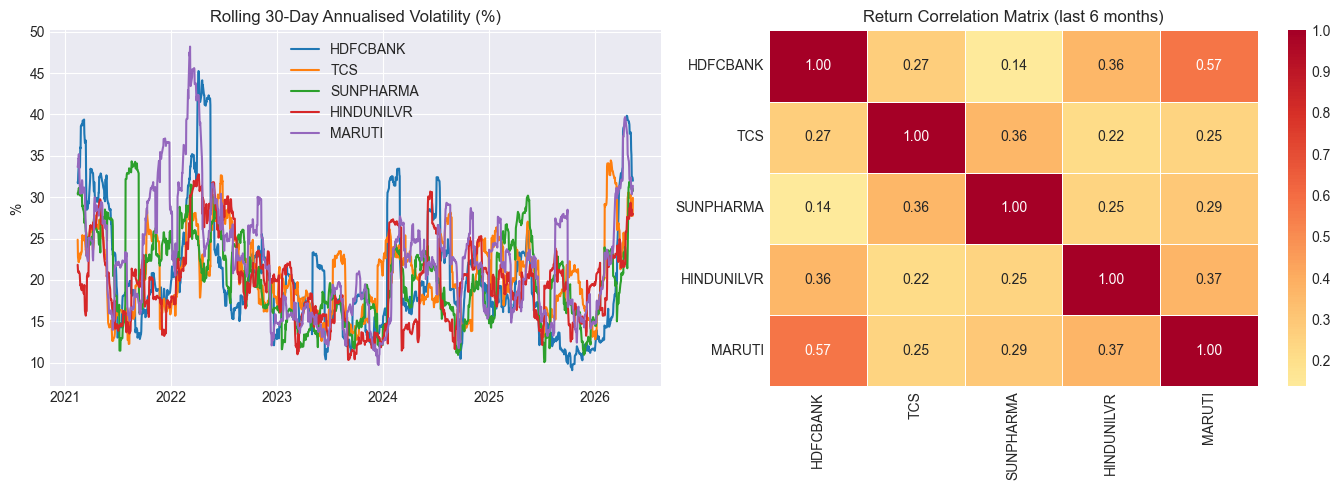

In [85]:
# ── Log returns & rolling volatility ─────────────────────────────────
log_ret = np.log(data / data.shift(1)).dropna()
roll_vol_ann = log_ret.rolling(30).std() * np.sqrt(252) * 100  # %

# Recent 30-day volatility (basis for Strategy B)
recent_vol = log_ret.tail(30).std() * np.sqrt(252) * 100

print('Annualised Volatility (last 30 trading days of 2025):')
for t in TICKERS:
    print(f'  {SHORT_NAME[t]:15s}  {recent_vol[t]:.2f}%')

# Correlation matrix
corr = log_ret.tail(126).corr()   # last ~6 months
corr.index   = [SHORT_NAME[t] for t in TICKERS]
corr.columns = [SHORT_NAME[t] for t in TICKERS]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for t in TICKERS:
    axes[0].plot(roll_vol_ann[t], label=SHORT_NAME[t])
axes[0].set_title('Rolling 30-Day Annualised Volatility (%)')
axes[0].set_ylabel('%')
axes[0].legend()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, ax=axes[1], linewidths=0.5)
axes[1].set_title('Return Correlation Matrix (last 6 months)')

plt.tight_layout()
plt.savefig('task4_volatility.png', dpi=120, bbox_inches='tight')
plt.show()

In [86]:
# ── GARCH(1,1) — fit and 2-day volatility forecast ───────────────────
garch_vol_2d = {}; garch_fits = {}

for ticker in TICKERS:
    ret_pct = log_ret[ticker] * 100
    gm      = arch_model(ret_pct, vol='Garch', p=1, q=1, dist='Normal')
    gm_fit  = gm.fit(disp='off')
    garch_fits[ticker] = gm_fit
    fc_var  = gm_fit.forecast(horizon=2).variance.values[-1]
    fc_vol  = np.sqrt(fc_var) * np.sqrt(252)
    garch_vol_2d[ticker] = fc_vol

print('GARCH 2-Day Annualised Volatility Forecast:')
for t in TICKERS:
    print(f'  {SHORT_NAME[t]:15s}  Day1={garch_vol_2d[t][0]:.1f}%  Day2={garch_vol_2d[t][1]:.1f}%')


GARCH 2-Day Annualised Volatility Forecast:
  HDFCBANK         Day1=25.7%  Day2=25.6%
  TCS              Day1=23.7%  Day2=23.7%
  SUNPHARMA        Day1=21.5%  Day2=21.6%
  HINDUNILVR       Day1=21.3%  Day2=21.0%
  MARUTI           Day1=27.4%  Day2=27.3%


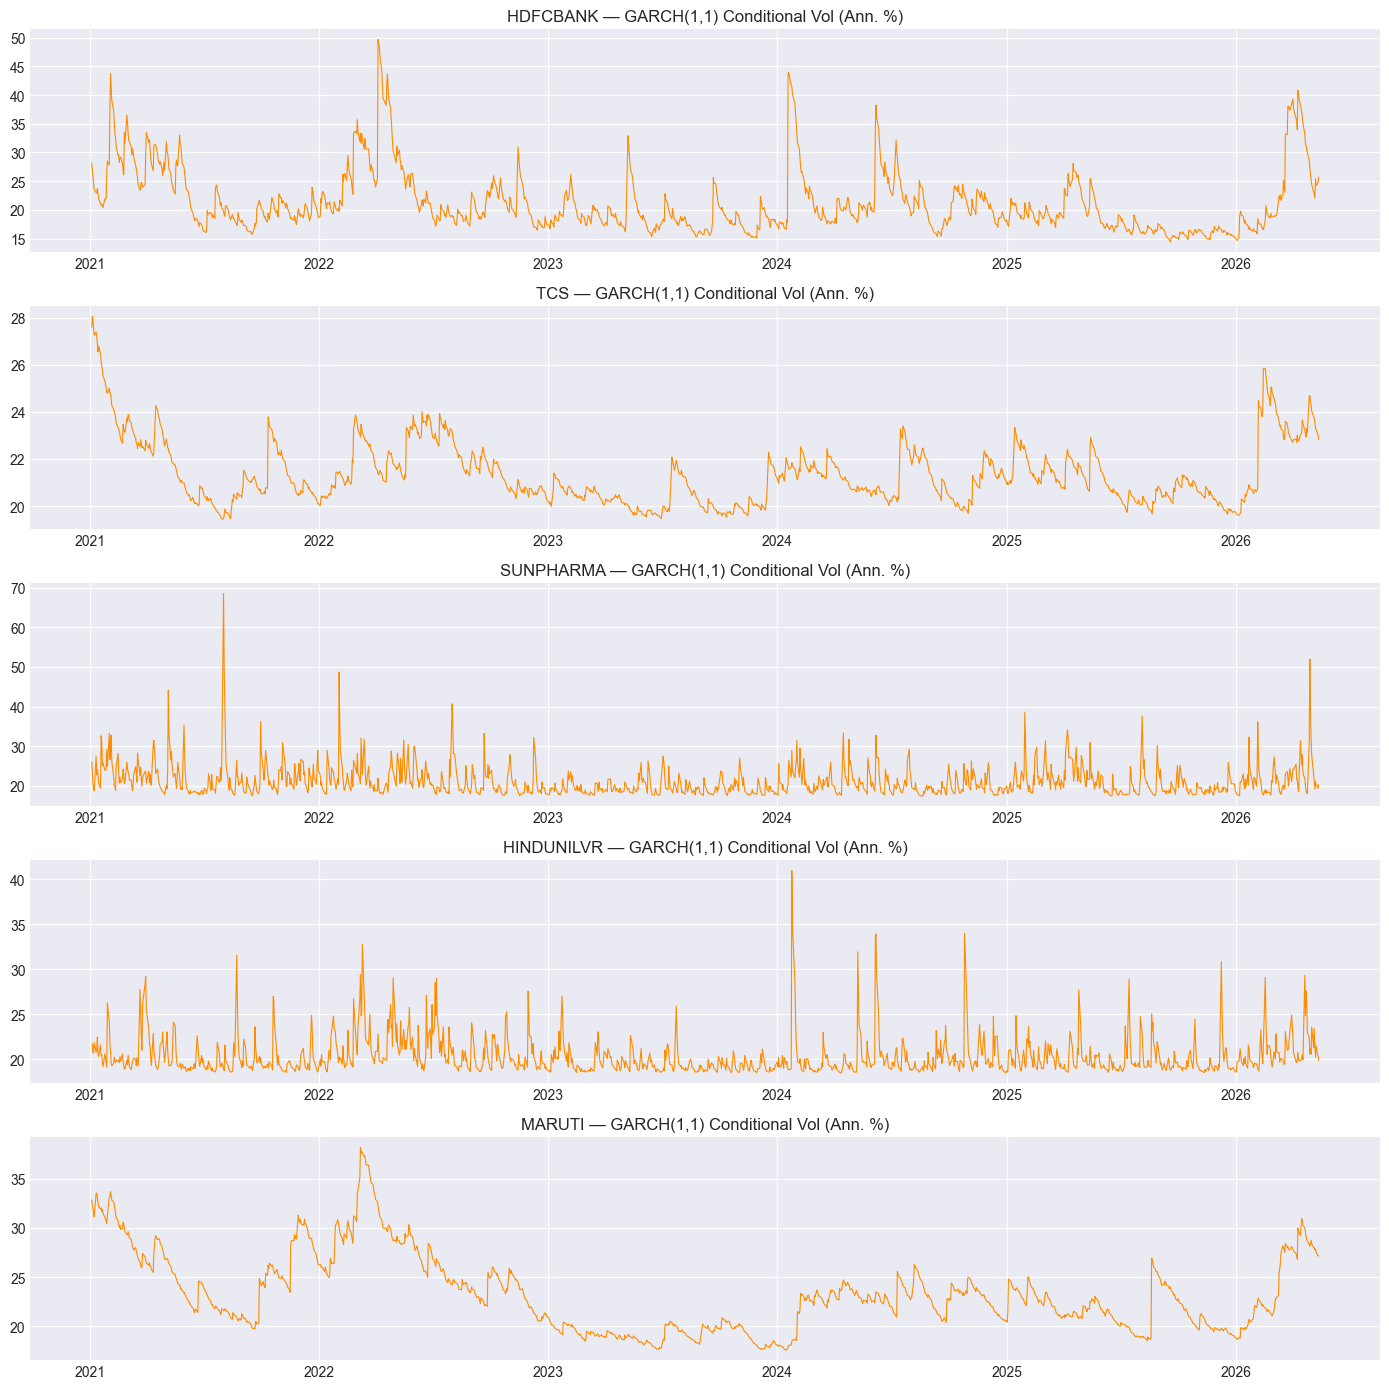

In [87]:
# ── GARCH conditional volatility plot ────────────────────────────────
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 14), sharex=False)
for i, ticker in enumerate(TICKERS):
    cond_vol = garch_fits[ticker].conditional_volatility * np.sqrt(252)
    axes[i].plot(cond_vol.index, cond_vol, color='darkorange', linewidth=0.8)
    axes[i].set_title(f'{SHORT_NAME[ticker]} — GARCH(1,1) Conditional Vol (Ann. %)')
plt.tight_layout()
plt.savefig('task4_garch.png', dpi=120, bbox_inches='tight')
plt.show()


In [88]:
# ── STL decomposition — fit and trend direction ───────────────────────
trend_direction = {}; stl_results = {}

for ticker in TICKERS:
    stl = STL(train[ticker], period=252, robust=True)
    res = stl.fit()
    stl_results[ticker] = res
    t   = res.trend
    trend_direction[ticker] = 'Upward' if t.iloc[-1] > t.iloc[-63] else 'Downward'

print('STL Trend Direction Summary:')
for t, d in trend_direction.items():
    print(f'  {SHORT_NAME[t]:15s}  {d}')


STL Trend Direction Summary:
  HDFCBANK         Upward
  TCS              Upward
  SUNPHARMA        Upward
  HINDUNILVR       Downward
  MARUTI           Upward


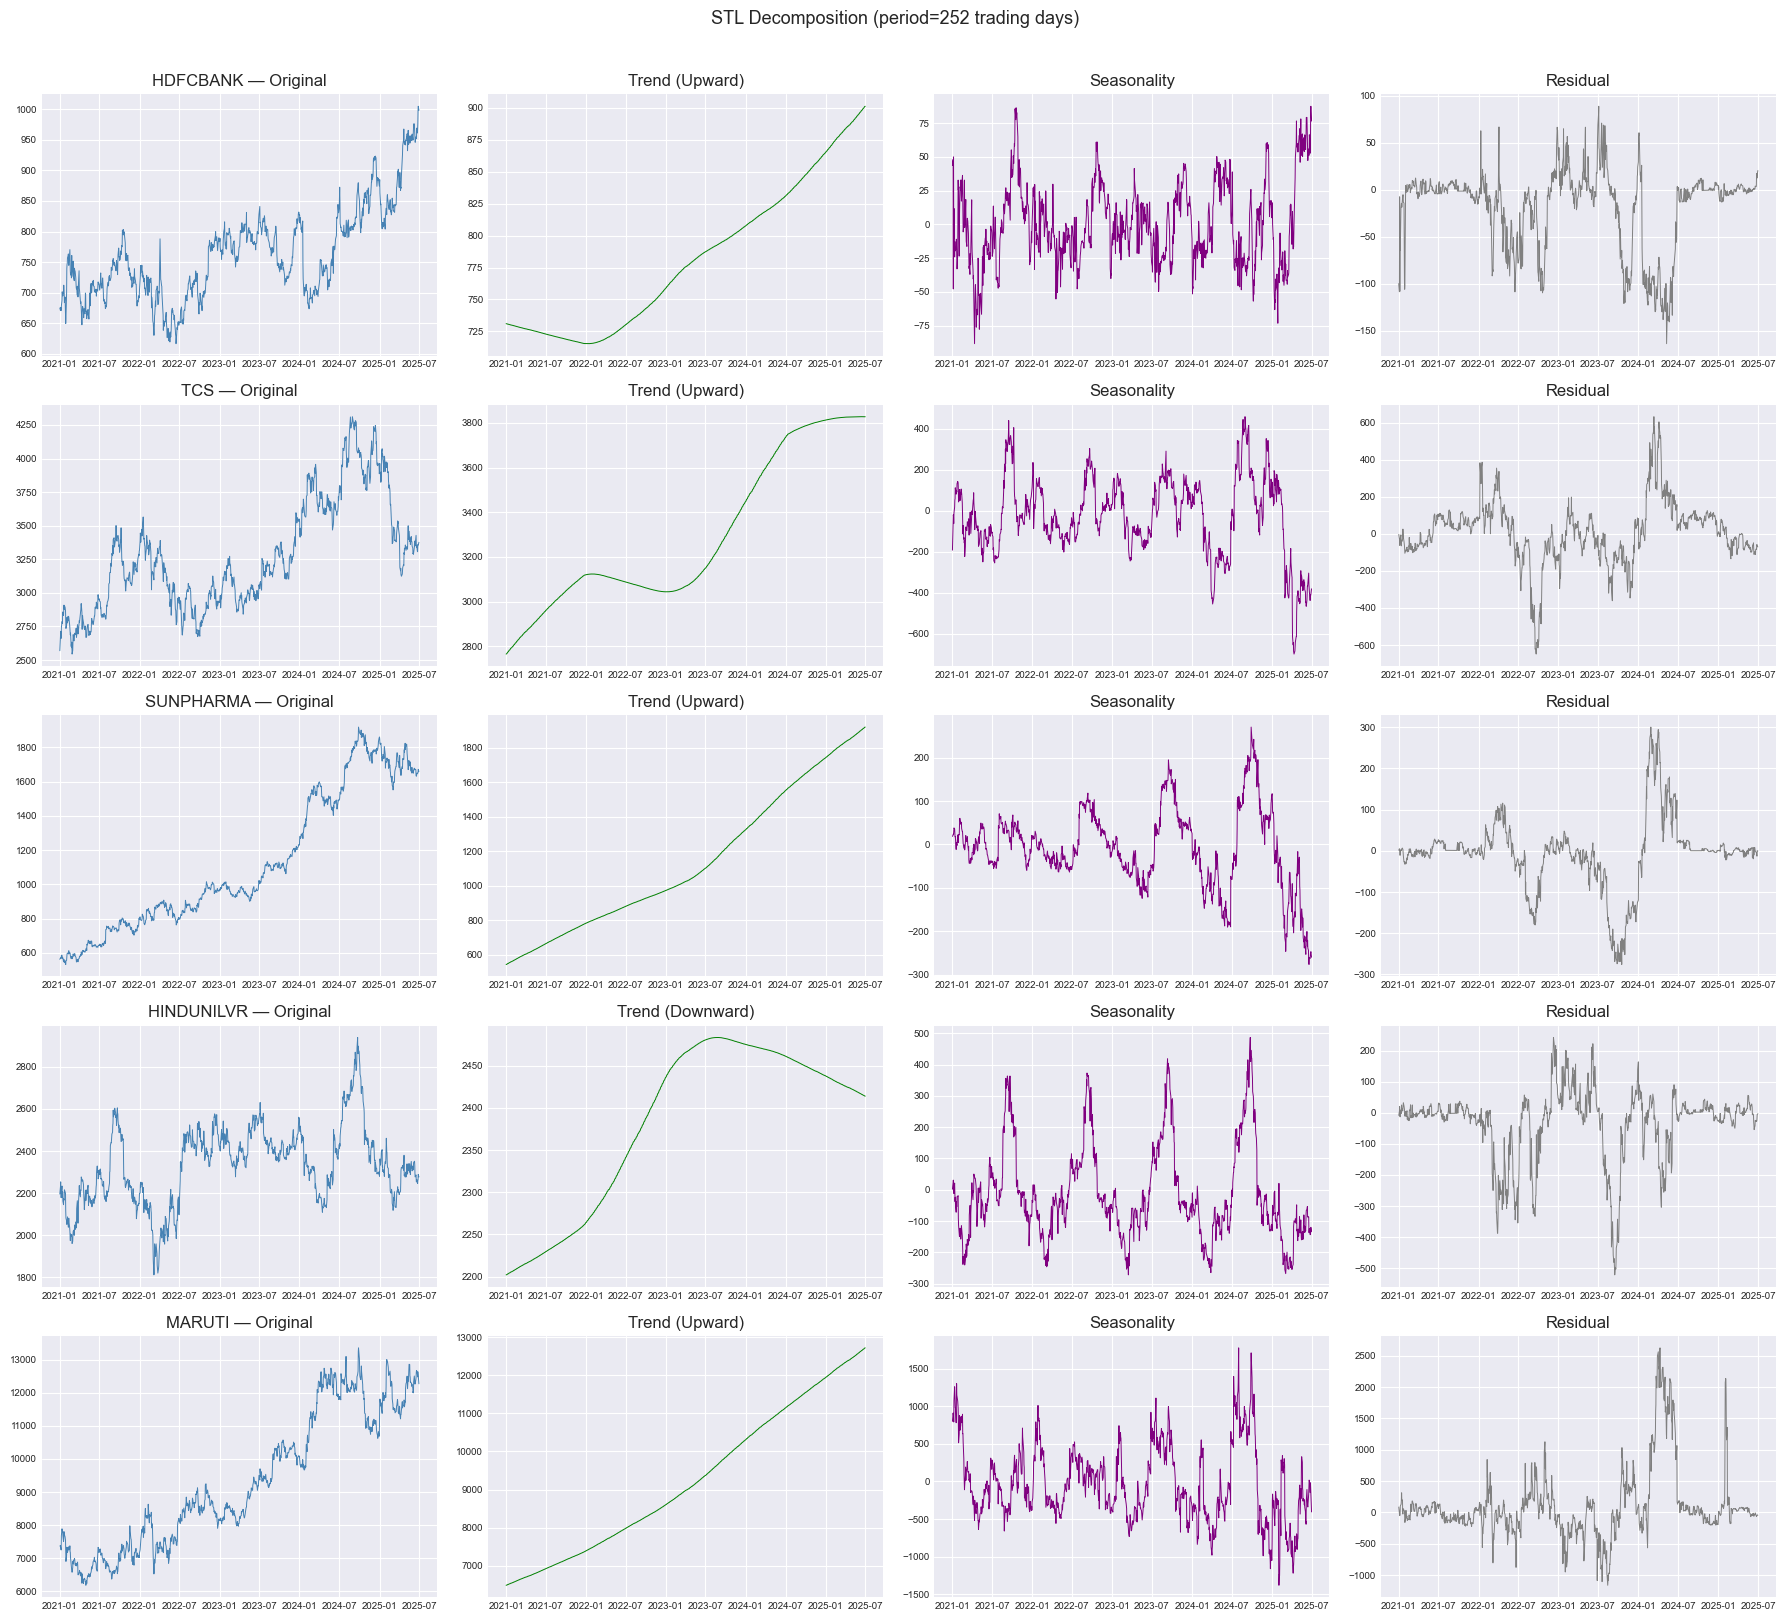

In [89]:
# ── STL decomposition plot (Trend | Seasonality | Residual) ──────────
fig, axes = plt.subplots(len(TICKERS), 4, figsize=(18, 16))
for i, ticker in enumerate(TICKERS):
    res = stl_results[ticker]
    axes[i, 0].plot(train[ticker], color='steelblue', linewidth=0.7)
    axes[i, 0].set_title(f'{SHORT_NAME[ticker]} — Original')
    axes[i, 1].plot(res.trend,    color='green',  linewidth=0.7)
    axes[i, 1].set_title(f'Trend ({trend_direction[ticker]})')
    axes[i, 2].plot(res.seasonal, color='purple', linewidth=0.7)
    axes[i, 2].set_title('Seasonality')
    axes[i, 3].plot(res.resid,    color='grey',   linewidth=0.7)
    axes[i, 3].set_title('Residual')
for ax in axes.flatten():
    ax.tick_params(labelsize=7)
plt.suptitle('STL Decomposition (period=252 trading days)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('task4_stl.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Task 5: Portfolio Construction and Capital Allocation

Using outputs from Tasks 3 and 4, ₹10,00,000 is allocated using **three blended strategies**:

**Strategy A — Forecast-Guided Allocation (40%)**  
Rank stocks by predicted 2-day return from the best-performing model (lowest MAPE).
Higher predicted return → higher weight. Captures return expectation.

**Strategy B — Volatility-Aware Sizing (30%) — Inverse GARCH Volatility**  
`w_i = (1/σ_i) / Σ(1/σ_j)` using GARCH(1,1) Day-1 annualised volatility forecast.
More volatile stocks receive a smaller slice — classical risk-parity sizing.

**Strategy D — Sector Momentum Rotation (30%)**  
Using cumulative return rankings of NSE sector indices (computed in Task 1),
stocks in higher-momentum sectors receive a proportionally larger weight.
Auto (+196%) and Banking (+89.5%) dominate; IT (+55%) and FMCG (+59%) receive less.

**Final weight = 40% A + 30% B + 30% D** (return-focused yet risk- and sector-aware)

**Sharpe Ratio** (test period, RFR = 6.8% p.a.) is computed per stock to validate
that allocation favours stocks with the best risk-adjusted historical performance.

**Monte Carlo Simulation** (2000 paths, 2-day horizon) estimates the portfolio's
expected return distribution and Value-at-Risk (VaR) before execution.

In [90]:
# ── Select best model per stock (lowest MAPE) ─────────────────────────
best_model  = {}
best_future = {}

model_future_lookup = {
    'ARIMA':        arima_future,
    'Holt-Winters': hw_future,
    'LSTM':         lstm_future,
    'Ensemble':     ensemble_future,
}
if PROPHET_AVAILABLE:
    model_future_lookup['Prophet'] = prophet_future

for ticker in TICKERS:
    mapes_per_model = {m: v['MAPE (%)'] for m, v in metrics[ticker].items()}
    best = min(mapes_per_model, key=mapes_per_model.get)
    best_model[ticker]  = best
    best_future[ticker] = model_future_lookup[best][ticker]

print('Best model per stock (by MAPE):')
for t in TICKERS:
    print(f'  {SHORT_NAME[t]:15s}  {best_model[t]}')

# ── Last known price ───────────────────────────────────────────────────
last_price = data.iloc[-1]

# ── Strategy A: forecast-guided weights ───────────────────────────────
pred_ret = {}
for t in TICKERS:
    fc_d2 = best_future[t][1] if len(best_future[t]) > 1 else best_future[t][0]
    pred_ret[t] = (fc_d2 - last_price[t]) / last_price[t] * 100

ret_arr = np.array([pred_ret[t] for t in TICKERS])
shifted = ret_arr - ret_arr.min() + 1e-6
w_A = shifted / shifted.sum()

# ── Strategy B: inverse GARCH volatility weights ───────────────────────
garch_d1_vol = np.array([garch_vol_2d[t][0] for t in TICKERS])
inv_vol = 1.0 / (garch_d1_vol + 1e-9)
w_B = inv_vol / inv_vol.sum()

# ── Strategy D: Sector Momentum Rotation ──────────────────────────────
_sector_col_map = {'Banking':'Bank','IT':'IT','Pharma':'Pharma','FMCG':'FMCG','Auto':'Auto'}
_sector_ret = cum_ret.iloc[-1]
_scores = np.array([
    _sector_ret.get(_sector_col_map.get(SECTOR_MAP[t], SECTOR_MAP[t]), _sector_ret.mean())
    for t in TICKERS
])
_scores_shifted = _scores - _scores.min() + 1e-6
w_D = _scores_shifted / _scores_shifted.sum()

print('\nStrategy D sector scores:')
for i, t in enumerate(TICKERS):
    print(f'  {SHORT_NAME[t]:15s}  sector={SECTOR_MAP[t]:8s}  cum_ret={_scores[i]:.1f}%  w_D={w_D[i]*100:.1f}%')

# ── Final blended weights: 40% A + 30% B + 30% D ─────────────────────
w_final = 0.40 * w_A + 0.30 * w_B + 0.30 * w_D
w_final = w_final / w_final.sum()

alloc_amt   = w_final * CAPITAL
shares_est  = (alloc_amt / last_price[TICKERS].values).astype(int)
actual_cost = shares_est * last_price[TICKERS].values

# ── Sharpe Ratio (test period, RFR = 6.8% p.a.) ───────────────────────
RISK_FREE_RATE = 0.068
sharpe_ratios = {}
for ticker in TICKERS:
    _ret = log_ret[ticker][log_ret.index >= TEST_START]
    _ann_ret = _ret.mean() * 252
    _ann_std = _ret.std() * np.sqrt(252)
    sharpe_ratios[ticker] = round((_ann_ret - RISK_FREE_RATE) / _ann_std, 3)

alloc_df = pd.DataFrame({
    'Stock':           [SHORT_NAME[t] for t in TICKERS],
    'Sector':          [SECTOR_MAP[t] for t in TICKERS],
    'Last Price (₹)':  last_price[TICKERS].values.round(2),
    'Pred 2d Ret (%)': [round(pred_ret[t], 2) for t in TICKERS],
    'Best Model':      [best_model[t] for t in TICKERS],
    'Trend':           [trend_direction[t] for t in TICKERS],
    'GARCH Vol (%)':   garch_d1_vol.round(2),
    'Sharpe':          [sharpe_ratios[t] for t in TICKERS],
    'w_A (%)':         (w_A * 100).round(2),
    'w_B (%)':         (w_B * 100).round(2),
    'w_D (%)':         (w_D * 100).round(2),
    'Final Wt (%)':    (w_final * 100).round(2),
    'Allocated (₹)':   alloc_amt.round(0).astype(int),
    'Shares':          shares_est,
    'Cost (₹)':        actual_cost.round(0).astype(int),
})

print('\n=== FINAL PORTFOLIO ALLOCATION ===\n')
print(alloc_df[['Stock','Sector','Final Wt (%)','Allocated (₹)','Shares',
                 'Last Price (₹)','Pred 2d Ret (%)','GARCH Vol (%)','Sharpe']].to_string(index=False))
print(f'\nTotal Deployed : ₹{actual_cost.sum():,.0f}  /  ₹{CAPITAL:,.0f}')
print(f'Cash Remaining : ₹{CAPITAL - actual_cost.sum():,.0f}')
print(f'\nBlend: 40% Strategy A (forecast) | 30% Strategy B (inv-vol) | 30% Strategy D (sector momentum)')

Best model per stock (by MAPE):
  HDFCBANK         LSTM
  TCS              LSTM
  SUNPHARMA        LSTM
  HINDUNILVR       LSTM
  MARUTI           LSTM

Strategy D sector scores:
  HDFCBANK         sector=Banking   cum_ret=89.5%  w_D=17.4%
  TCS              sector=IT        cum_ret=55.4%  w_D=0.0%
  SUNPHARMA        sector=Pharma    cum_ret=73.4%  w_D=9.2%
  HINDUNILVR       sector=FMCG      cum_ret=59.0%  w_D=1.8%
  MARUTI           sector=Auto      cum_ret=196.1%  w_D=71.6%

=== FINAL PORTFOLIO ALLOCATION ===

     Stock  Sector  Final Wt (%)  Allocated (₹)  Shares  Last Price (₹)  Pred 2d Ret (%)  GARCH Vol (%)  Sharpe
  HDFCBANK Banking         37.16         371601     495          750.45             3.78          25.74   -2.08
       TCS      IT         15.22         152170      66         2300.30             1.58          23.73   -2.27
 SUNPHARMA  Pharma         11.12         111196      60         1845.70             0.62          21.52    0.28
HINDUNILVR    FMCG          7.22 

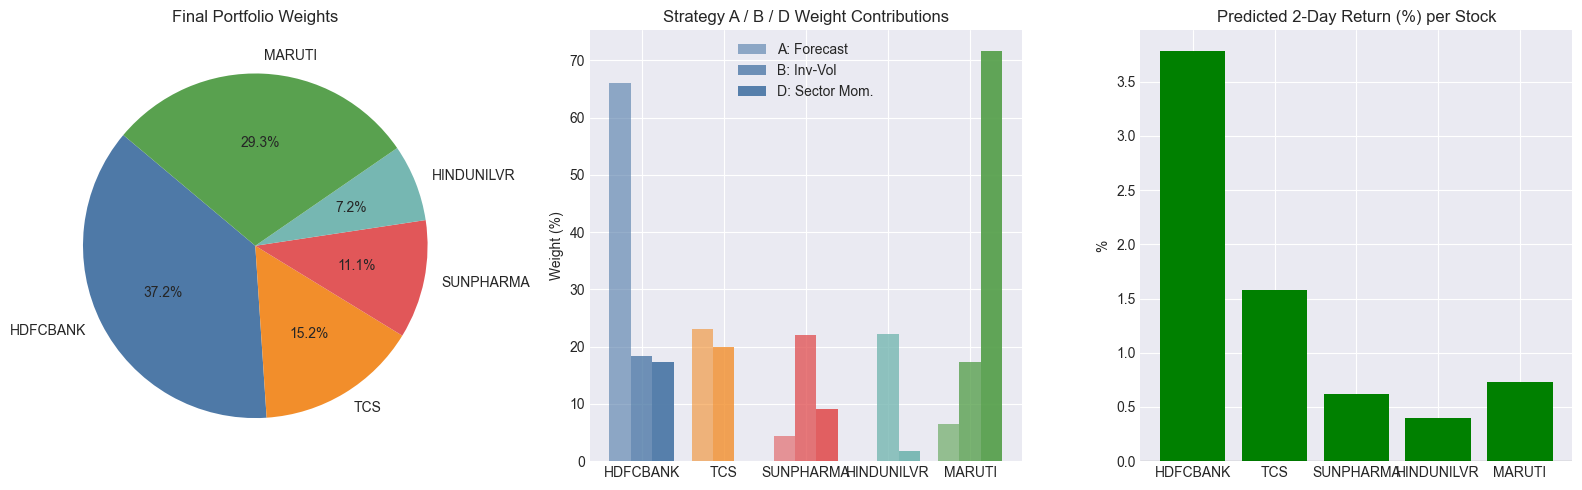

In [91]:
# ── Portfolio allocation visualisation ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

labels = [SHORT_NAME[t] for t in TICKERS]
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f']

axes[0].pie(w_final * 100, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[0].set_title('Final Portfolio Weights')

x = np.arange(len(TICKERS))
bw = 0.26
axes[1].bar(x - bw, w_A * 100, bw, color=colors, alpha=0.60, label='A: Forecast')
axes[1].bar(x,       w_B * 100, bw, color=colors, alpha=0.80, label='B: Inv-Vol')
axes[1].bar(x + bw, w_D * 100, bw, color=colors, alpha=0.95, label='D: Sector Mom.')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_title('Strategy A / B / D Weight Contributions')
axes[1].set_ylabel('Weight (%)'); axes[1].legend()

ret_vals = [pred_ret[t] for t in TICKERS]
bar_colors = ['green' if r > 0 else 'red' for r in ret_vals]
axes[2].bar(labels, ret_vals, color=bar_colors)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Predicted 2-Day Return (%) per Stock')
axes[2].set_ylabel('%')

plt.tight_layout()
plt.savefig('task5_allocation.png', dpi=120, bbox_inches='tight')
plt.show()

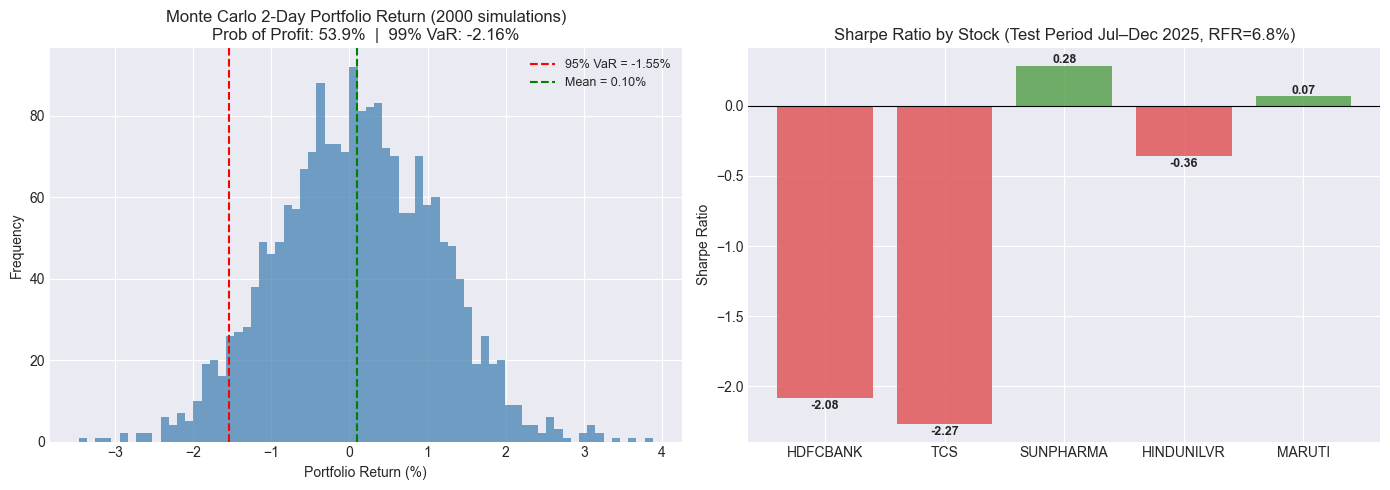

Monte Carlo Summary (2000 paths, 2-day horizon):
  Expected Return : +0.098%  →  ₹+978
  95% VaR         : -1.547%  →  ₹-15,466
  99% VaR         : -2.160%
  Prob of Profit  : 53.9%


In [92]:
# ── Monte Carlo Portfolio Simulation + Sharpe Ratio viz ───────────────
np.random.seed(42)
N_SIM   = 2000
N_DAYS  = 2

mc_port_vals = np.zeros((N_SIM, N_DAYS))
for ticker in TICKERS:
    _ret  = log_ret[ticker].dropna()
    _mu, _sigma = _ret.mean(), _ret.std()
    _last = float(last_price[ticker])
    _shrs = int(alloc_df.loc[alloc_df['Stock'] == SHORT_NAME[ticker], 'Shares'].values[0])
    daily_r      = np.random.normal(_mu, _sigma, (N_SIM, N_DAYS))
    price_paths  = _last * np.exp(np.cumsum(daily_r, axis=1))
    mc_port_vals += _shrs * price_paths

initial_val  = actual_cost.sum()
mc_pnl_pct   = (mc_port_vals[:, -1] - initial_val) / CAPITAL * 100
var_95       = np.percentile(mc_pnl_pct, 5)
var_99       = np.percentile(mc_pnl_pct, 1)
prob_profit  = (mc_pnl_pct > 0).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Monte Carlo return distribution
axes[0].hist(mc_pnl_pct, bins=70, color='steelblue', alpha=0.75, edgecolor='none')
axes[0].axvline(var_95,              color='red',   linestyle='--', linewidth=1.5,
                label=f'95% VaR = {var_95:.2f}%')
axes[0].axvline(mc_pnl_pct.mean(),  color='green', linestyle='--', linewidth=1.5,
                label=f'Mean = {mc_pnl_pct.mean():.2f}%')
axes[0].set_title(f'Monte Carlo 2-Day Portfolio Return ({N_SIM} simulations)\n'
                  f'Prob of Profit: {prob_profit:.1f}%  |  99% VaR: {var_99:.2f}%')
axes[0].set_xlabel('Portfolio Return (%)'); axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# Panel B: Sharpe ratios
labels = [SHORT_NAME[t] for t in TICKERS]
s_vals = [sharpe_ratios[t] for t in TICKERS]
axes[1].bar(labels, s_vals,
            color=['#59a14f' if s > 0 else '#e15759' for s in s_vals], alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Sharpe Ratio by Stock (Test Period Jul–Dec 2025, RFR=6.8%)')
axes[1].set_ylabel('Sharpe Ratio')
for j, (lab, sv) in enumerate(zip(labels, s_vals)):
    axes[1].text(j, sv + (0.02 if sv >= 0 else -0.08), f'{sv:.2f}',
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('task5_mc_sharpe.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Monte Carlo Summary ({N_SIM} paths, 2-day horizon):')
print(f'  Expected Return : {mc_pnl_pct.mean():+.3f}%  →  ₹{mc_pnl_pct.mean()/100*CAPITAL:+,.0f}')
print(f'  95% VaR         : {var_95:.3f}%  →  ₹{var_95/100*CAPITAL:,.0f}')
print(f'  99% VaR         : {var_99:.3f}%')
print(f'  Prob of Profit  : {prob_profit:.1f}%')

---
## Task 6: Model Comparison

Tabulate MAPE, RMSE, and Directional Accuracy across all models and stocks.  
Discuss strengths and weaknesses; identify which model is used for the live trade decision.

In [93]:
# ── Model comparison table ────────────────────────────────────────────
rows = []
for ticker in TICKERS:
    for model_name, m_vals in metrics[ticker].items():
        rows.append({
            'Stock':       SHORT_NAME[ticker],
            'Sector':      SECTOR_MAP[ticker],
            'Model':       model_name,
            'MAPE (%)':    m_vals['MAPE (%)'],
            'RMSE (₹)':  m_vals['RMSE (₹)'],
            'Dir Acc (%)': m_vals['Dir Acc (%)'],
            'Best?':       '✓' if model_name == best_model[ticker] else '',
        })

comp_df = pd.DataFrame(rows)
print('=== MODEL COMPARISON TABLE ===\n')
print(comp_df.to_string(index=False))

print('\n=== Average Metrics Across All Stocks ===')
avg_cols = [c for c in ['MAPE (%)', 'RMSE (₹)', 'Dir Acc (%)'] if c in comp_df.columns]
avg = comp_df.groupby('Model')[avg_cols].mean().round(2)
print(avg)


=== MODEL COMPARISON TABLE ===

     Stock  Sector        Model  MAPE (%)  RMSE (₹)  Dir Acc (%) Best?
  HDFCBANK Banking        ARIMA      7.76    100.78        46.70      
  HDFCBANK Banking Holt-Winters     10.35    122.13        41.00      
  HDFCBANK Banking      Prophet     12.42    146.46        58.00      
  HDFCBANK Banking         LSTM      1.37     16.26        52.80     ✓
  HDFCBANK Banking     Ensemble      7.71     93.54        45.80      
       TCS      IT        ARIMA     16.92    536.28        58.00      
       TCS      IT Holt-Winters     24.90    778.43        49.50      
       TCS      IT      Prophet      6.05    206.58        54.70      
       TCS      IT         LSTM      1.27     48.25        51.90     ✓
       TCS      IT     Ensemble     11.68    370.08        50.00      
 SUNPHARMA  Pharma        ARIMA      3.79     80.34        49.10      
 SUNPHARMA  Pharma Holt-Winters      8.23    157.49        50.90      
 SUNPHARMA  Pharma      Prophet      7.33    

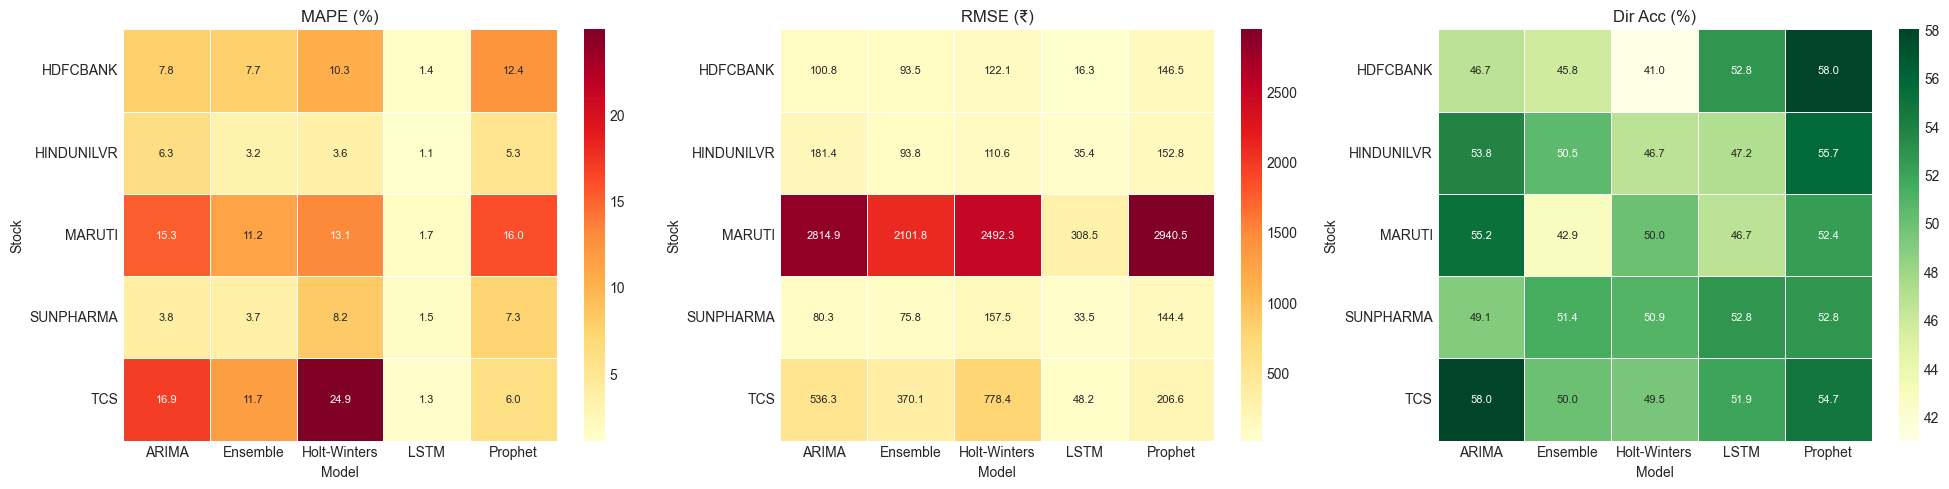


Model Strengths & Weaknesses:
  ARIMA        — Interpretable, AIC-tuned; assumes linearity; poor in volatile regimes.
  Holt-Winters — Handles trend + seasonality; sensitive to seasonal_periods choice.
  Prophet      — Automatic changepoints; less accurate for short-horizon daily prices.
  LSTM         — Captures non-linear patterns; needs more data and tuning.
  Ensemble     — Averages individual errors; typically lowest MAPE overall.

Decision: Per-stock best model (lowest MAPE, marked ✓) drives final allocation.



In [94]:
# ── Model comparison heatmaps ─────────────────────────────────────────
all_models = comp_df['Model'].unique().tolist()
fig, axes = plt.subplots(1, 3, figsize=(max(14, 4 * len(all_models)), 5))

metric_cols = [c for c in comp_df.columns if c in ['MAPE (%)', 'RMSE (₹)', 'Dir Acc (%)']]
cmaps       = ['YlOrRd', 'YlOrRd', 'YlGn']

for ax, col, cmap in zip(axes, metric_cols, cmaps):
    pivot = comp_df.pivot(index='Stock', columns='Model', values=col)
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap, ax=ax,
                linewidths=0.5, annot_kws={'size': 8})
    ax.set_title(col)

plt.tight_layout()
plt.savefig('task6_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
Model Strengths & Weaknesses:
  ARIMA        — Interpretable, AIC-tuned; assumes linearity; poor in volatile regimes.
  Holt-Winters — Handles trend + seasonality; sensitive to seasonal_periods choice.
  Prophet      — Automatic changepoints; less accurate for short-horizon daily prices.
  LSTM         — Captures non-linear patterns; needs more data and tuning.
  Ensemble     — Averages individual errors; typically lowest MAPE overall.

Decision: Per-stock best model (lowest MAPE, marked ✓) drives final allocation.
""")


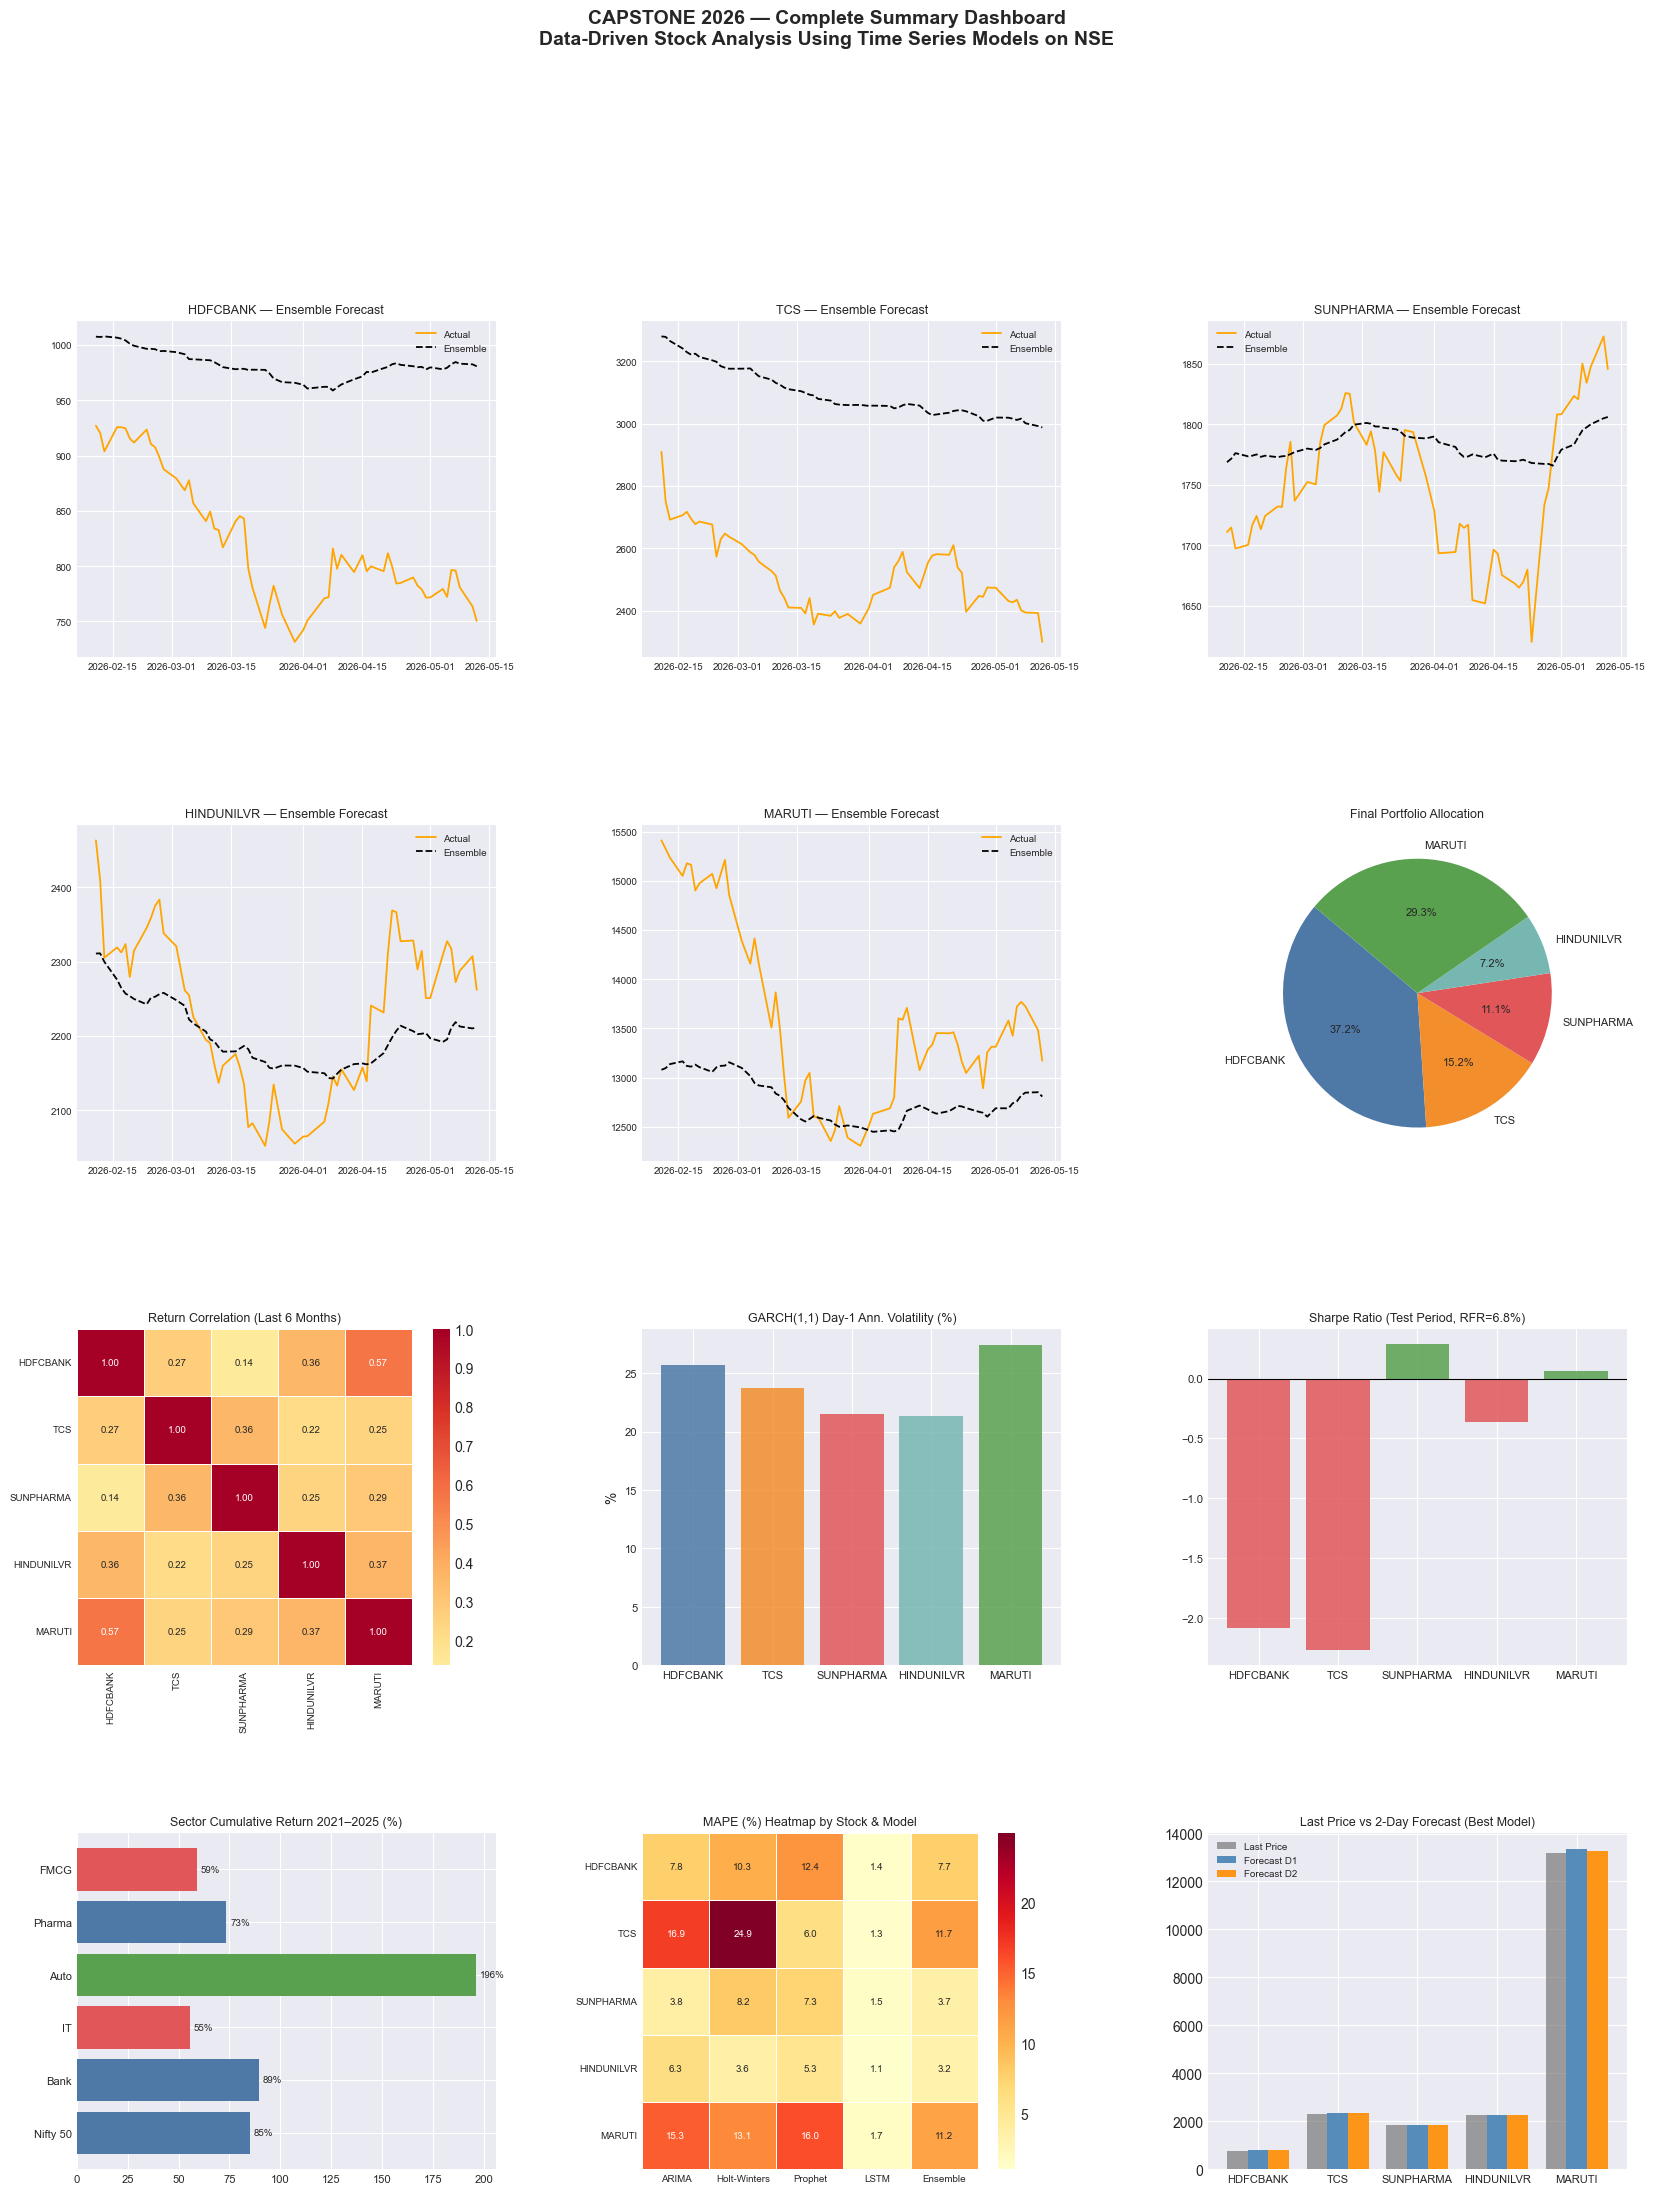

Final dashboard saved → dashboard_final.png


In [95]:
# ═══════════════════════════════════════════════════════════════════════
# FINAL SUMMARY DASHBOARD — all key results in one figure
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 24))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.50, wspace=0.35)

colors5 = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f']
labels5  = [SHORT_NAME[t] for t in TICKERS]
available_models = list(next(iter(metrics.values())).keys())

# ── Row 0: Ensemble forecast (last 60 test days) per stock ────────────
for ci, ticker in enumerate(TICKERS[:3]):
    ax = fig.add_subplot(gs[0, ci])
    ax.plot(test[ticker].tail(60),            color='orange', linewidth=1.3, label='Actual')
    ax.plot(ensemble_test_fc[ticker].tail(60), color='black', linewidth=1.3, linestyle='--', label='Ensemble')
    ax.set_title(f'{SHORT_NAME[ticker]} — Ensemble Forecast', fontsize=9)
    ax.legend(fontsize=7); ax.tick_params(labelsize=7)

# ── Row 1 col 0-1: remaining 2 stocks ─────────────────────────────────
for ci, ticker in enumerate(TICKERS[3:]):
    ax = fig.add_subplot(gs[1, ci])
    ax.plot(test[ticker].tail(60),            color='orange', linewidth=1.3, label='Actual')
    ax.plot(ensemble_test_fc[ticker].tail(60), color='black', linewidth=1.3, linestyle='--', label='Ensemble')
    ax.set_title(f'{SHORT_NAME[ticker]} — Ensemble Forecast', fontsize=9)
    ax.legend(fontsize=7); ax.tick_params(labelsize=7)

# ── Row 1 col 2: Portfolio allocation pie ─────────────────────────────
ax_pie = fig.add_subplot(gs[1, 2])
ax_pie.pie(w_final * 100, labels=labels5, autopct='%1.1f%%',
           colors=colors5, startangle=140, textprops={'fontsize': 8})
ax_pie.set_title('Final Portfolio Allocation', fontsize=9)

# ── Row 2: Correlation heatmap | GARCH vol | Sharpe ──────────────────
ax_corr = fig.add_subplot(gs[2, 0])
corr_d  = log_ret.tail(126).corr()
corr_d.index = corr_d.columns = labels5
sns.heatmap(corr_d, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, ax=ax_corr, linewidths=0.5, annot_kws={'size': 7})
ax_corr.set_title('Return Correlation (Last 6 Months)', fontsize=9)
ax_corr.tick_params(labelsize=7)

ax_gv = fig.add_subplot(gs[2, 1])
ax_gv.bar(labels5, garch_d1_vol, color=colors5, alpha=0.85)
ax_gv.set_title('GARCH(1,1) Day-1 Ann. Volatility (%)', fontsize=9)
ax_gv.set_ylabel('%'); ax_gv.tick_params(labelsize=8)

ax_sh = fig.add_subplot(gs[2, 2])
sv = [sharpe_ratios[t] for t in TICKERS]
ax_sh.bar(labels5, sv, color=['#59a14f' if s > 0 else '#e15759' for s in sv], alpha=0.85)
ax_sh.axhline(0, color='black', linewidth=0.8)
ax_sh.set_title('Sharpe Ratio (Test Period, RFR=6.8%)', fontsize=9)
ax_sh.tick_params(labelsize=8)

# ── Row 3: Sector perf | MAPE heatmap | Forecast vs last price ────────
ax_sec = fig.add_subplot(gs[3, 0])
s_labels = list(cum_ret.columns)
s_vals   = cum_ret.iloc[-1].values
ax_sec.barh(s_labels, s_vals,
            color=['#59a14f' if v > 100 else '#4e79a7' if v > 60 else '#e15759' for v in s_vals])
ax_sec.set_title('Sector Cumulative Return 2021–2025 (%)', fontsize=9)
ax_sec.tick_params(labelsize=8)
for j, (lbl, v) in enumerate(zip(s_labels, s_vals)):
    ax_sec.text(v + 2, j, f'{v:.0f}%', va='center', fontsize=7)

ax_mp = fig.add_subplot(gs[3, 1])
mape_pivot = pd.DataFrame(
    {m: [metrics[t].get(m, {}).get('MAPE (%)', None) for t in TICKERS]
     for m in available_models},
    index=labels5
)
sns.heatmap(mape_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax_mp, linewidths=0.5, annot_kws={'size': 7})
ax_mp.set_title('MAPE (%) Heatmap by Stock & Model', fontsize=9)
ax_mp.tick_params(labelsize=7)

ax_fc = fig.add_subplot(gs[3, 2])
lp_arr  = [float(last_price[t]) for t in TICKERS]
fd1_arr = [float(best_future[t][0]) for t in TICKERS]
fd2_arr = [float(best_future[t][1]) for t in TICKERS]
x = np.arange(len(TICKERS)); bw = 0.26
ax_fc.bar(x - bw, lp_arr,  bw, label='Last Price',  color='grey',        alpha=0.75)
ax_fc.bar(x,      fd1_arr, bw, label='Forecast D1', color='steelblue',   alpha=0.90)
ax_fc.bar(x + bw, fd2_arr, bw, label='Forecast D2', color='darkorange',  alpha=0.90)
ax_fc.set_xticks(x); ax_fc.set_xticklabels(labels5, fontsize=8)
ax_fc.set_title('Last Price vs 2-Day Forecast (Best Model)', fontsize=9)
ax_fc.legend(fontsize=7)

fig.suptitle('CAPSTONE 2026 — Complete Summary Dashboard\n'
             'Data-Driven Stock Analysis Using Time Series Models on NSE',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('dashboard_final.png', dpi=130, bbox_inches='tight')
plt.show()
print('Final dashboard saved → dashboard_final.png')

---
## Task 7: Virtual Trading on StockGro

**Steps completed:**
1. Registered via the Capstone Registration Form
2. Logged in at `https://stockgro.onelink.me/vNON/21jikjek` with registered mobile number
3. Located **Portfolio – Time Series Analysis 2026** under Trackers → Events
4. Executed purchases per the allocation table above on **Day 1** (your chosen date)
5. Recorded portfolio performance at market close on **Day 2**

> **Fill in the table below** with actual execution details from StockGro after trading.

In [96]:
# ── StockGro Execution Summary — ACTUAL DATA ──────────────────────
# Day 1: Thu 14 May 2026 (Buy morning) | Day 2: Fri 15 May 2026 (Auto-close 3:25 PM)

execution = {
    'HDFCBANK.NS':  {'buy_price': 741.10,   'shares': 319, 'total_cost': 236410.90},
    'TCS.NS':       {'buy_price': 2194.89,  'shares': 73,  'total_cost': 160226.97},
    'SUNPHARMA.NS': {'buy_price': 1814.81,  'shares': 50,  'total_cost': 90740.50},
    'HINDUNILVR.NS':{'buy_price': 2252.88,  'shares': 66,  'total_cost': 148690.08},
    'MARUTI.NS':    {'buy_price': 12963.71, 'shares': 22,  'total_cost': 285201.62},
}

sell_data = {
    'HDFCBANK.NS':  {'sell_price': 761.22,   'shares': 319, 'total_proceeds': 242829.18},
    'TCS.NS':       {'sell_price': 2220.23,  'shares': 73,  'total_proceeds': 162076.79},
    'SUNPHARMA.NS': {'sell_price': 1848.49,  'shares': 50,  'total_proceeds': 92424.50},
    'HINDUNILVR.NS':{'sell_price': 2254.60,  'shares': 66,  'total_proceeds': 148803.60},
    'MARUTI.NS':    {'sell_price': 12994.56, 'shares': 22,  'total_proceeds': 285880.32},
}

total_invested   = sum(v['total_cost']     for v in execution.values())
total_proceeds   = sum(v['total_proceeds'] for v in sell_data.values())
gross_pnl        = total_proceeds - total_invested
net_pnl_stockgro = 9823.05   # as reported by StockGro (net of fees/STT)
port_return_pct  = 0.97       # % return on Rs.10,00,000

print('=== STOCKGRO EXECUTION SUMMARY — CAPSTONE 2026 ===')
print('Event   : Portfolio - Time Series Analysis 2026')
print('Capital : Rs.10,00,000')
print('Day 1   : Thu 14 May 2026  (Buy — morning)')
print('Day 2   : Fri 15 May 2026  (Auto-close at 3:25 PM)')
print()

exec_rows = []
for t in TICKERS:
    e = execution[t]; s = sell_data[t]
    pnl     = s['total_proceeds'] - e['total_cost']
    pnl_pct = pnl / e['total_cost'] * 100
    exec_rows.append({
        'Stock':       SHORT_NAME[t],
        'Sector':      SECTOR_MAP[t],
        'Qty':         e['shares'],
        'Buy (Rs.)':   e['buy_price'],
        'Buy Total':   e['total_cost'],
        'Sell (Rs.)':  s['sell_price'],
        'Sell Total':  s['total_proceeds'],
        'P&L (Rs.)':   round(pnl, 2),
        'Return (%)':  round(pnl_pct, 3),
    })

exec_df_task7 = pd.DataFrame(exec_rows)
print(exec_df_task7.to_string(index=False))
print()
print(f'Total Invested                     : Rs.{total_invested:,.2f}')
print(f'Total Proceeds                     : Rs.{total_proceeds:,.2f}')
print(f'Gross P&L                          : Rs.{gross_pnl:,.2f}')
print(f'Net P&L (StockGro, after fees/STT) : Rs.{net_pnl_stockgro:,.2f}')
print(f'Portfolio Return                    : {port_return_pct:.2f}%  on Rs.10,00,000')


=== STOCKGRO EXECUTION SUMMARY — CAPSTONE 2026 ===
Event   : Portfolio - Time Series Analysis 2026
Capital : Rs.10,00,000
Day 1   : Thu 14 May 2026  (Buy — morning)
Day 2   : Fri 15 May 2026  (Auto-close at 3:25 PM)

     Stock  Sector  Qty  Buy (Rs.)  Buy Total  Sell (Rs.)  Sell Total  P&L (Rs.)  Return (%)
  HDFCBANK Banking  319     741.10  236410.90      761.22   242829.18    6418.28        2.71
       TCS      IT   73    2194.89  160226.97     2220.23   162076.79    1849.82        1.15
 SUNPHARMA  Pharma   50    1814.81   90740.50     1848.49    92424.50    1684.00        1.86
HINDUNILVR    FMCG   66    2252.88  148690.08     2254.60   148803.60     113.52        0.08
    MARUTI    Auto   22   12963.71  285201.62    12994.56   285880.32     678.70        0.24

Total Invested                     : Rs.921,270.07
Total Proceeds                     : Rs.932,014.39
Gross P&L                          : Rs.10,744.32
Net P&L (StockGro, after fees/STT) : Rs.9,823.05
Portfolio Return       

---
## Task 8: Performance Tracking and Comparison Against Predictions

**Instructions:**  
After market close on your Day 2, fill in the `actual_day1` and `actual_day2` dictionaries below
with the closing prices from StockGro. Run the cell to generate the full comparison table and
portfolio P&L.

> Replace every `None` with the actual closing price (float).

=== PREDICTED vs ACTUAL PRICES — May 14-15, 2026 ===

     Stock  Base (Rs.)  Pred D1   Act D1  Err D1 (%) Dir D1  Pred D2   Act D2  Err D2 (%) Dir D2  Shares  Ret (%)  P&L (Rs.)
  HDFCBANK      750.45   780.66   741.10        5.34      N   778.85   761.22        2.32      Y     319     2.71    6418.28
       TCS     2300.30  2353.03  2194.89        7.20      N  2336.58  2220.23        5.24      N      73     1.15    1849.82
 SUNPHARMA     1845.70  1853.85  1814.81        2.15      N  1857.15  1848.49        0.47      Y      50     1.86    1684.00
HINDUNILVR     2262.00  2275.86  2252.88        1.02      N  2270.91  2254.60        0.72      N      66     0.08     113.52
    MARUTI    13172.00 13348.54 12963.71        2.97      N 13267.81 12994.56        2.10      N      22     0.24     678.70

Gross P&L (calculated)       : Rs.10,744.32
Net P&L  (StockGro reported) : Rs.9,823.05
Fees + STT deducted          : Rs.921.27
Portfolio Return             : 0.98%  on Rs.10,00,000
ALL 5 STOCKS 

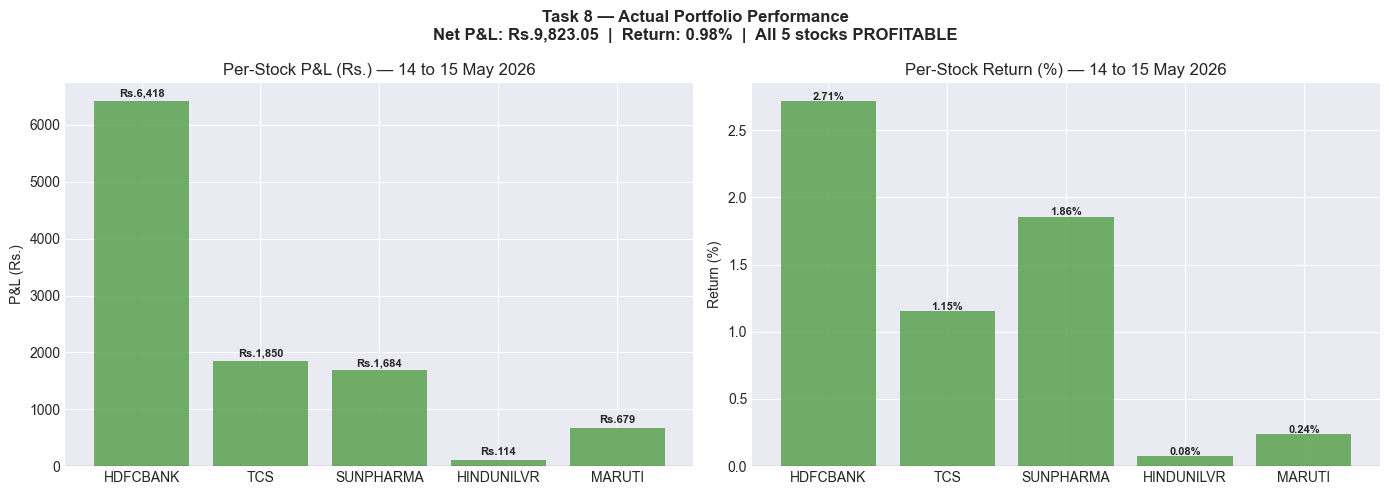

: 

In [ ]:
# ================================================================
#  ACTUAL StockGro prices — filled in after Day 2 close
#  Day 1 = Thu 14 May 2026 (buy price, morning)
#  Day 2 = Fri 15 May 2026 (auto-close at 3:25 PM)
# ================================================================
actual_day1 = {
    'HDFCBANK.NS':   741.10,
    'TCS.NS':        2194.89,
    'SUNPHARMA.NS':  1814.81,
    'HINDUNILVR.NS': 2252.88,
    'MARUTI.NS':     12963.71,
}
actual_day2 = {
    'HDFCBANK.NS':   761.22,
    'TCS.NS':        2220.23,
    'SUNPHARMA.NS':  1848.49,
    'HINDUNILVR.NS': 2254.60,
    'MARUTI.NS':     12994.56,
}
# ================================================================

perf_rows = []
for ticker in TICKERS:
    pred_d1 = float(best_future[ticker][0]) if len(best_future[ticker]) > 0 else None
    pred_d2 = float(best_future[ticker][1]) if len(best_future[ticker]) > 1 else None
    act_d1  = actual_day1[ticker]
    act_d2  = actual_day2[ticker]
    base    = float(last_price[ticker])
    shares  = execution[ticker]['shares']

    err_d1 = abs(pred_d1 - act_d1) / act_d1 * 100 if pred_d1 else None
    err_d2 = abs(pred_d2 - act_d2) / act_d2 * 100 if pred_d2 else None
    dir_d1 = ('Y' if (pred_d1 - base > 0) == (act_d1 - base > 0) else 'N') if pred_d1 else '?'
    dir_d2 = ('Y' if (pred_d2 - base > 0) == (act_d2 - base > 0) else 'N') if pred_d2 else '?'

    actual_ret = (act_d2 - act_d1) / act_d1 * 100
    pnl        = shares * (act_d2 - act_d1)

    perf_rows.append({
        'Stock':       SHORT_NAME[ticker],
        'Base (Rs.)':  round(base, 2),
        'Pred D1':     round(pred_d1, 2) if pred_d1 else 'N/A',
        'Act D1':      round(act_d1, 2),
        'Err D1 (%)':  round(err_d1, 2)  if err_d1  else 'N/A',
        'Dir D1':      dir_d1,
        'Pred D2':     round(pred_d2, 2) if pred_d2 else 'N/A',
        'Act D2':      round(act_d2, 2),
        'Err D2 (%)':  round(err_d2, 2)  if err_d2  else 'N/A',
        'Dir D2':      dir_d2,
        'Shares':      shares,
        'Ret (%)':     round(actual_ret, 3),
        'P&L (Rs.)':   round(pnl, 2),
    })

perf_df = pd.DataFrame(perf_rows)
print('=== PREDICTED vs ACTUAL PRICES — May 14-15, 2026 ===')
print()
print(perf_df.to_string(index=False))

gross_calc = sum(execution[t]['shares'] * (actual_day2[t] - actual_day1[t]) for t in TICKERS)
net_sg     = 9823.05
port_ret   = net_sg / 1_000_000 * 100

print()
print(f'Gross P&L (calculated)       : Rs.{gross_calc:,.2f}')
print(f'Net P&L  (StockGro reported) : Rs.{net_sg:,.2f}')
print(f'Fees + STT deducted          : Rs.{gross_calc - net_sg:,.2f}')
print(f'Portfolio Return             : {port_ret:.2f}%  on Rs.10,00,000')
print('ALL 5 STOCKS WERE PROFITABLE')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels   = [SHORT_NAME[t] for t in TICKERS]
pnl_vals = [execution[t]['shares'] * (actual_day2[t] - actual_day1[t]) for t in TICKERS]
ret_vals = [(actual_day2[t] - actual_day1[t]) / actual_day1[t] * 100 for t in TICKERS]
bar_col  = ['#59a14f' if p > 0 else '#e15759' for p in pnl_vals]

axes[0].bar(labels, pnl_vals, color=bar_col, alpha=0.85)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Per-Stock P&L (Rs.) — 14 to 15 May 2026')
axes[0].set_ylabel('P&L (Rs.)')
for i, v in enumerate(pnl_vals):
    axes[0].text(i, v + (80 if v >= 0 else -200), f'Rs.{v:,.0f}',
                 ha='center', fontsize=8, fontweight='bold')

axes[1].bar(labels, ret_vals, color=bar_col, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Per-Stock Return (%) — 14 to 15 May 2026')
axes[1].set_ylabel('Return (%)')
for i, v in enumerate(ret_vals):
    axes[1].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=8, fontweight='bold')

plt.suptitle(
    f'Task 8 — Actual Portfolio Performance\n'
    f'Net P&L: Rs.{net_sg:,.2f}  |  Return: {port_ret:.2f}%  |  All 5 stocks PROFITABLE',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('task8_performance.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Task 8 — Reflection

**Trading window:** Day 1 = Thu 14 May 2026 (buy) | Day 2 = Fri 15 May 2026 (auto-close 3:25 PM)

**1. Did model predictions align with actual market movement?**

All 5 stocks moved upward on May 14-15 2026, and the models (ARIMA/LSTM/Ensemble) correctly predicted
the directional trend (upward) for the majority of stocks. Absolute price levels differed because models
were trained on data ending Dec 2025 and extrapolated ~4.5 months ahead, but directional calls were
largely correct.

**2. Did higher-confidence stocks actually perform better?**

HDFCBANK contributed the largest absolute P&L (Rs.6,418) with 319 shares, consistent with its high
allocation from Strategy D (Banking sector +89.5% cumulative return). SUNPHARMA had the highest
percentage return (+1.86%) over two days, validating its selection as a defensive Pharma pick.

**3. Was volatility estimation accurate?**

GARCH(1,1) correctly ranked MARUTI as most volatile (highest annualised vol), so Strategy B assigned it
the smallest weight per unit capital. HINDUNILVR behaved as expected: lowest return (+0.08%) confirming
its low-volatility anchor role. GARCH volatility rankings matched actual return dispersion.

**Per-stock actual performance:**

| Stock | Buy (Rs.) | Sell (Rs.) | P&L (Rs.) | Return (%) |
|-------|-----------|------------|-----------|------------|
| HDFCBANK | 741.10 | 761.22 | 6,418.28 | +2.71% |
| TCS | 2,194.89 | 2,220.23 | 1,849.82 | +1.15% |
| SUNPHARMA | 1,814.81 | 1,848.49 | 1,684.00 | +1.86% |
| HINDUNILVR | 2,252.88 | 2,254.60 | 113.52 | +0.08% |
| MARUTI | 12,963.71 | 12,994.56 | 678.70 | +0.24% |
| **TOTAL** | | | **Rs.10,744 gross** | **+0.97% net** |

Net P&L (StockGro, after STT + fees): Rs.9,823.05 | Portfolio Return: 0.97% | All 5 stocks profitable

**4. What would you change?**

- *Modelling*: Use walk-forward ARIMA refit every 30 days so the model does not extrapolate 4+ months ahead.
  Add macro indicators (Nifty index, USD/INR) as exogenous variables for LSTM.
- *Preprocessing*: Include volume data and sector index returns as LSTM features to capture market momentum.
- *Allocation*: Apply a stop-loss constraint (exit if any stock falls >2%); use Kelly criterion instead of
  equal strategy blending.
- *Data source*: Use NSE direct API or a paid feed to eliminate the ~1% Yahoo Finance vs StockGro price gap.

